# E. coli Core FluxTransformer Architecture Sweep

Train and compare current-architecture FluxTransformer models of different sizes on one E. coli core simulated-data file.

Main workflow: load `2026-06-25_ecoli_core_training_data_980621_samples.csv`, train each configured model, plot biomass-flux diagnostics with the model size in the title, compute pooled flux metrics (`R2`, `MAE`, `RMSE`), and finish with a comparison table across all sizes.

In [1]:
import copy
import gc
import random
import time
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

from flux_transformer import FluxTransformer
from train_flux_transformer import load_data

%matplotlib inline

In [2]:
DATA_PATH = "./data/2026-06-25_ecoli_core_training_data_980621_samples.csv"
BIOMASS_TOKEN = "Biomass_Ecoli_core_flux"

SEED = 42
TEST_SIZE = 0.2
BATCH_SIZE = 256
EVAL_BATCH_SIZE = 512
NUM_EPOCHS = 100
PATIENCE = 10
LEARNING_RATE = 1e-4
DROPOUT = 0.02
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 1.0
MAX_SAMPLES = None  # Set to an integer for a quick smoke run; keep None for the full file.
KEEP_MODELS = False
BIOMASS_PANEL_SAMPLE_COUNT = 20_000

MODEL_CONFIGS = [
    {"name": "d32_h4_l2_ff640", "d_model": 32, "n_heads": 4, "n_layers": 2, "d_ff": 640},

    {"name": "d64_h4_l2_ff640", "d_model": 64, "n_heads": 4, "n_layers": 2, "d_ff": 640},
    {"name": "d64_h8_l2_ff640", "d_model": 64, "n_heads": 8, "n_layers": 2, "d_ff": 640},
    {"name": "d64_h8_l3_ff640", "d_model": 64, "n_heads": 8, "n_layers": 3, "d_ff": 640},

    {"name": "d128_h4_l2_ff640", "d_model": 128, "n_heads": 4, "n_layers": 2, "d_ff": 640},
    {"name": "d128_h8_l2_ff640", "d_model": 128, "n_heads": 8, "n_layers": 2, "d_ff": 640},
    {"name": "d128_h8_l3_ff640", "d_model": 128, "n_heads": 8, "n_layers": 3, "d_ff": 640},
    {"name": "d128_h8_l3_ff1024", "d_model": 128, "n_heads": 8, "n_layers": 3, "d_ff": 1024},

    {"name": "d256_h4_l2_ff640", "d_model": 256, "n_heads": 4, "n_layers": 2, "d_ff": 640},
    {"name": "d256_h8_l3_ff640", "d_model": 256, "n_heads": 8, "n_layers": 3, "d_ff": 640},
    {"name": "d256_h8_l3_ff1024", "d_model": 256, "n_heads": 8, "n_layers": 3, "d_ff": 1024},
    {"name": "d256_h8_l4_ff1024", "d_model": 256, "n_heads": 8, "n_layers": 4, "d_ff": 1024},
]

RUN_DATE = date.today().isoformat()
PLOT_DIR = Path("./pics") / RUN_DATE / "ecoli_core_architecture_sweep"
RESULTS_DIR = Path("./insights/ecoli_core_architecture_sweep")
PLOT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = RESULTS_DIR / "model_size_comparison.csv"

print(f"Device available: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Model configs: {len(MODEL_CONFIGS)}")

Device available: cuda
Model configs: 12


## Load Data

The current FluxTransformer vocabulary is the output-flux token list. Medium inputs are injected into matching `*_flux` token slots using the current `load_data` mapping.

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X, y, input_cols, outputs, input_token_indices, out_indices = load_data(DATA_PATH)

if MAX_SAMPLES is not None:
    X = X[:MAX_SAMPLES]
    y = y[:MAX_SAMPLES]
    print(f"Using MAX_SAMPLES={MAX_SAMPLES}; X={X.shape}, y={y.shape}")

assert BIOMASS_TOKEN in outputs, f"Missing biomass token: {BIOMASS_TOKEN}"
assert X.shape[1] == len(outputs), "X token dimension must match output token count."
assert y.shape[1] == len(outputs), "y token dimension must match output token count."

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    pin_memory=(device.type == "cuda"),
)

del X, y, X_train_np, X_test_np, y_train_np, y_test_np
gc.collect()

biomass_idx = outputs.index(BIOMASS_TOKEN)
vocab_size = len(outputs)
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Input columns: {len(input_cols)}")
print(f"Output/vocab tokens: {vocab_size}")
print(f"Biomass token index: {biomass_idx}")
print(f"Injected input token indices: {input_token_indices}")

Using device: cuda

Loaded data with 980621 samples from ./data/2026-06-25_ecoli_core_training_data_980621_samples.csv
Extracted input columns count:  20
Extracted output columns count: 95
Medium constraints are injected into these token indices (in outputs order):
[27, 25, 32, 37, 19, 21, 38, 26, 33, 23, 20, 24, 28, 29, 22, 30, 31, 34, 35, 36]
Training samples: 784,496
Test samples: 196,125
Input columns: 20
Output/vocab tokens: 95
Biomass token index: 12
Injected input token indices: [27, 25, 32, 37, 19, 21, 38, 26, 33, 23, 20, 24, 28, 29, 22, 30, 31, 34, 35, 36]


## Helpers

These helpers use the current `FluxTransformer` contract: model input is `(batch, vocab_size, 1)`, predictions are returned for selected token indices, and last-layer scalar predictions are compared with the matching target token values.

In [4]:
def empty_cache():
    if device.type == "cuda":
        torch.cuda.empty_cache()


def format_elapsed(seconds):
    seconds = int(seconds)
    hours, rem = divmod(seconds, 3600)
    minutes, seconds = divmod(rem, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"


def model_param_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_model(config):
    return FluxTransformer(
        vocab_size=vocab_size,
        input_token_indices=input_token_indices,
        d_model=config["d_model"],
        n_heads=config["n_heads"],
        n_layers=config["n_layers"],
        d_ff=config["d_ff"],
        dropout=DROPOUT,
    ).to(device)


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    criterion = nn.HuberLoss()
    total_loss = 0.0
    n_samples = 0

    context = torch.enable_grad() if training else torch.inference_mode()
    with context:
        for batch_X_cpu, batch_y_cpu in loader:
            batch_X = batch_X_cpu.to(device, non_blocking=True)
            batch_y = batch_y_cpu.to(device, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            preds_all_layers, selected_indices = model(batch_X.unsqueeze(-1), output_subset=None)
            pred_last = preds_all_layers[:, :, -1]
            target = batch_y.index_select(1, selected_indices)
            loss = criterion(pred_last, target)

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()

            batch_size = batch_X.size(0)
            total_loss += float(loss.item()) * batch_size
            n_samples += batch_size

            del batch_X, batch_y, preds_all_layers, pred_last, target, loss

    return total_loss / max(1, n_samples)


def train_model_config(config):
    set_seed(SEED)
    model = make_model(config)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=(0.9, 0.98),
        eps=1e-9,
        weight_decay=WEIGHT_DECAY,
    )

    train_losses = []
    test_losses = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = 0
    no_improve = 0
    started = time.time()

    print("=" * 80)
    print(f"Training {config['name']}")
    print(f"Parameters: {model_param_count(model):,}")

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss = run_epoch(model, test_loader, optimizer=None)
        train_losses.append(train_loss)
        test_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            no_improve = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        print(
            f"{config['name']} | epoch {epoch:03d}/{NUM_EPOCHS} | "
            f"train={train_loss:.6f} | val={val_loss:.6f} | "
            f"best={best_val_loss:.6f} @ {best_epoch} | "
            f"no_improve={no_improve} | elapsed={format_elapsed(time.time() - started)}"
        )

        if no_improve >= PATIENCE:
            print(f"Early stopping {config['name']} at epoch {epoch}; best_epoch={best_epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()

    meta = {
        "best_epoch": int(best_epoch),
        "best_val_loss": float(best_val_loss),
        "epochs_ran": int(len(train_losses)),
        "train_losses": train_losses,
        "test_losses": test_losses,
        "elapsed_sec": float(time.time() - started),
    }
    return model, meta


def plot_loss_curves(train_losses, test_losses, config):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(train_losses, label="Train")
    ax.plot(test_losses, label="Validation")
    ax.set_yscale("log")
    ax.set_title(f"Loss Curves: {config['name']}", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Huber loss")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def predict_and_score(model, config):
    y_true_mean = float(y_test.double().mean().item())
    y_true_sst = float(torch.sum((y_test.double() - y_true_mean) ** 2).item())

    sse = 0.0
    sae = 0.0
    count = 0
    biomass_true_parts = []
    biomass_pred_parts = []
    inverse_perm = None

    model.eval()
    with torch.inference_mode():
        for batch_X_cpu, batch_y_cpu in test_loader:
            batch_X = batch_X_cpu.to(device, non_blocking=True)
            preds_all_layers, selected_indices = model(batch_X.unsqueeze(-1), output_subset=None)
            pred_last = preds_all_layers[:, :, -1]

            if inverse_perm is None:
                selected_np = selected_indices.detach().cpu().numpy().astype(np.int64)
                if selected_np.size != vocab_size:
                    raise RuntimeError(f"Expected {vocab_size} selected tokens, got {selected_np.size}.")
                inv = np.full(vocab_size, -1, dtype=np.int64)
                inv[selected_np] = np.arange(selected_np.size, dtype=np.int64)
                if (inv < 0).any():
                    missing = np.where(inv < 0)[0].tolist()
                    raise RuntimeError(f"Model output is missing token indices: {missing[:10]}")
                inverse_perm = torch.tensor(inv, dtype=torch.long, device=pred_last.device)

            pred_full = pred_last.index_select(1, inverse_perm).detach().cpu()
            target_full = batch_y_cpu
            diff = pred_full.double() - target_full.double()

            sse += float(torch.sum(diff ** 2).item())
            sae += float(torch.sum(torch.abs(diff)).item())
            count += int(diff.numel())

            biomass_true_parts.append(target_full[:, biomass_idx].numpy())
            biomass_pred_parts.append(pred_full[:, biomass_idx].numpy())

            del batch_X, preds_all_layers, pred_last, pred_full, target_full, diff

    biomass_true = np.concatenate(biomass_true_parts)
    biomass_pred = np.concatenate(biomass_pred_parts)

    overall_r2 = 1.0 - (sse / y_true_sst) if y_true_sst > 0 else float("nan")
    overall_mae = sae / count
    overall_rmse = float(np.sqrt(sse / count))

    biomass_r2 = r2_score(biomass_true, biomass_pred)
    biomass_mae = mean_absolute_error(biomass_true, biomass_pred)
    biomass_rmse = root_mean_squared_error(biomass_true, biomass_pred)

    metrics = {
        "overall_r2": float(overall_r2),
        "overall_mae": float(overall_mae),
        "overall_rmse": float(overall_rmse),
        "biomass_r2": float(biomass_r2),
        "biomass_mae": float(biomass_mae),
        "biomass_rmse": float(biomass_rmse),
    }
    return metrics, biomass_true, biomass_pred


def plot_biomass_diagnostics(y_true, y_pred, config):
    residuals = y_true - y_pred
    label = f"Biomass {config['name']}"

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    lo = min(float(y_true.min()), float(y_pred.min()))
    hi = max(float(y_true.max()), float(y_pred.max()))
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color="royalblue")
    axs[0, 0].plot([lo, hi], [lo, hi], "k--", lw=2)
    axs[0, 0].set_title(f"True vs Predicted: {label}", fontsize=14)
    axs[0, 0].set_xlabel("True value")
    axs[0, 0].set_ylabel("Predicted")
    axs[0, 0].grid(alpha=0.2)

    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color="darkorange", s=6)
    axs[0, 1].axhline(y=0, color="r", linestyle="-")
    axs[0, 1].set_title(f"Residuals: {label}", fontsize=14)
    axs[0, 1].set_xlabel("True value")
    axs[0, 1].set_ylabel("Residuals")
    axs[0, 1].grid(alpha=0.2)

    sns.histplot(residuals, kde=True, ax=axs[1, 0], color="indianred")
    axs[1, 0].set_title(f"Prediction Error Distribution: {label}", fontsize=14)
    axs[1, 0].set_xlabel("Prediction error")
    axs[1, 0].grid(alpha=0.2)

    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], color="mediumseagreen")
    axs[1, 1].set_title(f"True Value Distribution: {label}", fontsize=14)
    axs[1, 1].set_xlabel("True value")
    axs[1, 1].grid(alpha=0.2)

    fig.tight_layout()
    plt.show()
    plt.close(fig)


def summarize_model_config(config):
    probe = FluxTransformer(
        vocab_size=vocab_size,
        input_token_indices=input_token_indices,
        d_model=config["d_model"],
        n_heads=config["n_heads"],
        n_layers=config["n_layers"],
        d_ff=config["d_ff"],
        dropout=DROPOUT,
    )
    params = model_param_count(probe)
    del probe
    return {**config, "n_params": int(params)}

## Planned Model Sizes

In [5]:
config_df = pd.DataFrame([summarize_model_config(config) for config in MODEL_CONFIGS])
display(config_df)

,name,d_model,n_heads,n_layers,d_ff,n_params
0,d32_h4_l2_ff640,32,4,2,640,97582
1,d64_h4_l2_ff640,64,4,2,640,207694
2,d64_h8_l2_ff640,64,8,2,640,207702
3,d64_h8_l3_ff640,64,8,3,640,308513
4,d128_h4_l2_ff640,128,4,2,640,477070
5,d128_h8_l2_ff640,128,8,2,640,477078
6,d128_h8_l3_ff640,128,8,3,640,709537
7,d128_h8_l3_ff1024,128,8,3,1024,1007905
8,d256_h4_l2_ff640,256,4,2,640,1212430
9,d256_h8_l3_ff640,256,8,3,640,1806497


## Run Architecture Sweep

This cell trains each configuration, plots the biomass diagnostic, computes pooled flux metrics, and writes an incremental CSV after each model.

Training d32_h4_l2_ff640
Parameters: 97,582
d32_h4_l2_ff640 | epoch 001/100 | train=3.112802 | val=1.689953 | best=1.689953 @ 1 | no_improve=0 | elapsed=00:01:21
d32_h4_l2_ff640 | epoch 002/100 | train=1.576640 | val=1.293065 | best=1.293065 @ 2 | no_improve=0 | elapsed=00:02:42
d32_h4_l2_ff640 | epoch 003/100 | train=1.256094 | val=1.042136 | best=1.042136 @ 3 | no_improve=0 | elapsed=00:04:13
d32_h4_l2_ff640 | epoch 004/100 | train=1.061919 | val=0.863312 | best=0.863312 @ 4 | no_improve=0 | elapsed=00:05:49
d32_h4_l2_ff640 | epoch 005/100 | train=0.919722 | val=0.765871 | best=0.765871 @ 5 | no_improve=0 | elapsed=00:07:32
d32_h4_l2_ff640 | epoch 006/100 | train=0.837778 | val=0.695283 | best=0.695283 @ 6 | no_improve=0 | elapsed=00:09:14
d32_h4_l2_ff640 | epoch 007/100 | train=0.775554 | val=0.645432 | best=0.645432 @ 7 | no_improve=0 | elapsed=00:11:00
d32_h4_l2_ff640 | epoch 008/100 | train=0.726804 | val=0.603036 | best=0.603036 @ 8 | no_improve=0 | elapsed=00:12:47
d32_h4_l2_ff

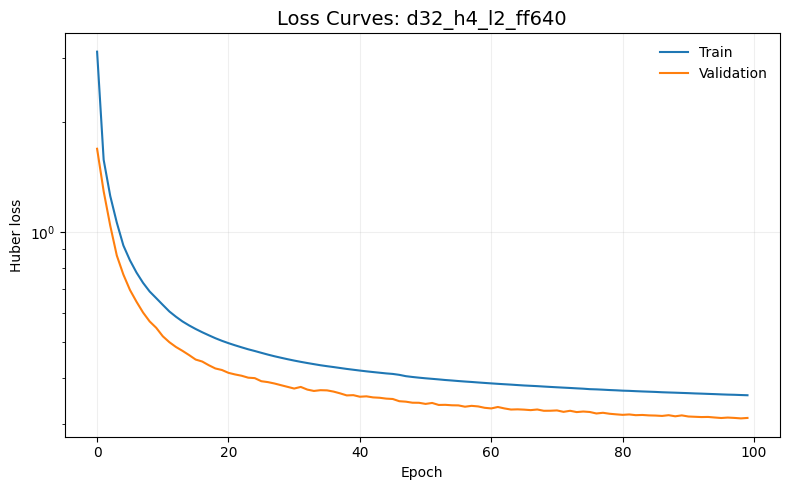

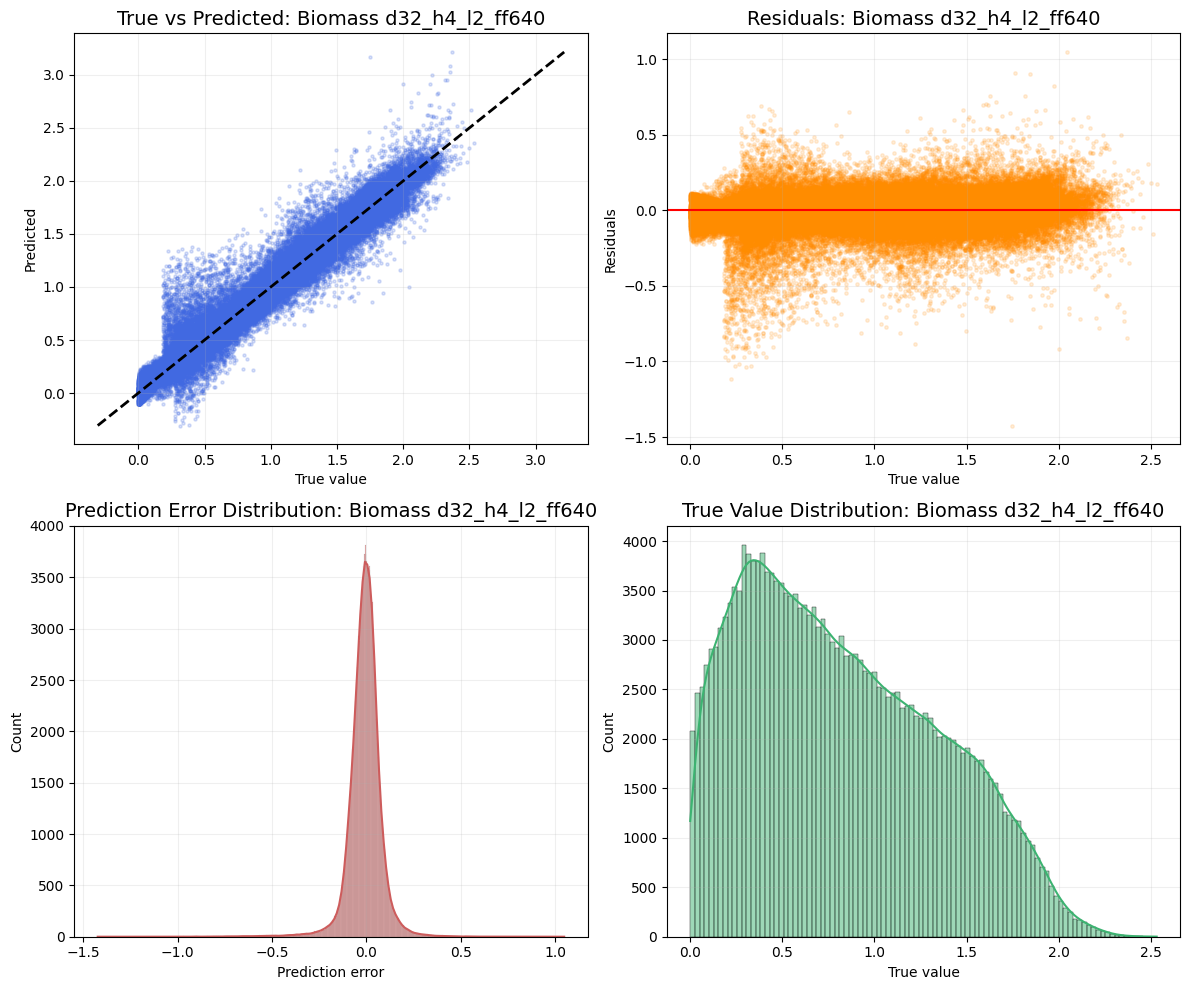

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024


d32_h4_l2_ff640 | overall R2=0.9734 | MAE=0.453076 | RMSE=1.912937 | biomass R2=0.9714
Training d64_h4_l2_ff640
Parameters: 207,694
d64_h4_l2_ff640 | epoch 001/100 | train=2.396488 | val=1.471982 | best=1.471982 @ 1 | no_improve=0 | elapsed=00:02:28
d64_h4_l2_ff640 | epoch 002/100 | train=1.307935 | val=1.027452 | best=1.027452 @ 2 | no_improve=0 | elapsed=00:04:58
d64_h4_l2_ff640 | epoch 003/100 | train=1.004597 | val=0.821008 | best=0.821008 @ 3 | no_improve=0 | elapsed=00:07:26
d64_h4_l2_ff640 | epoch 004/100 | train=0.841200 | val=0.689845 | best=0.689845 @ 4 | no_improve=0 | elapsed=00:09:56
d64_h4_l2_ff640 | epoch 005/100 | train=0.740596 | val=0.615353 | best=0.615353 @ 5 | no_improve=0 | elapsed=00:12:24
d64_h4_l2_ff640 | epoch 006/100 | train=0.675220 | val=0.551796 | best=0.551796 @ 6 | no_improve=0 | elapsed=00:14:57
d64_h4_l2_ff640 | epoch 007/100 | train=0.622257 | val=0.521892 | best=0.521892 @ 7 | no_improve=0 | elapsed=00:17:25
d64_h4_l2_ff640 | epoch 008/100 | train=0.

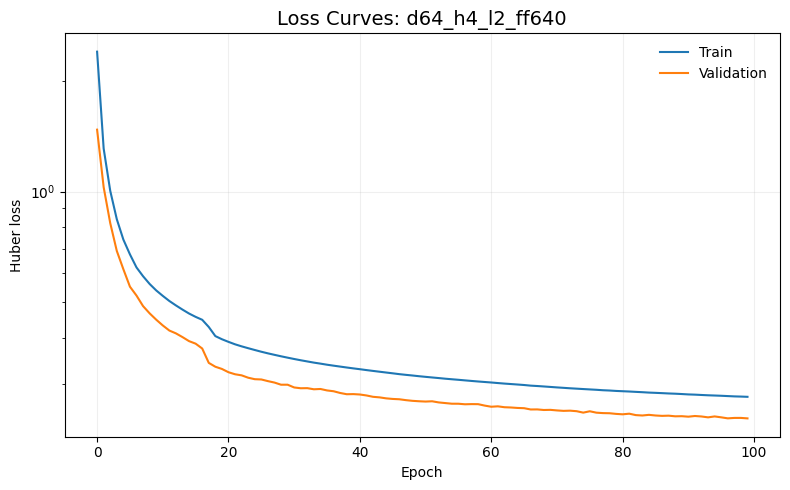

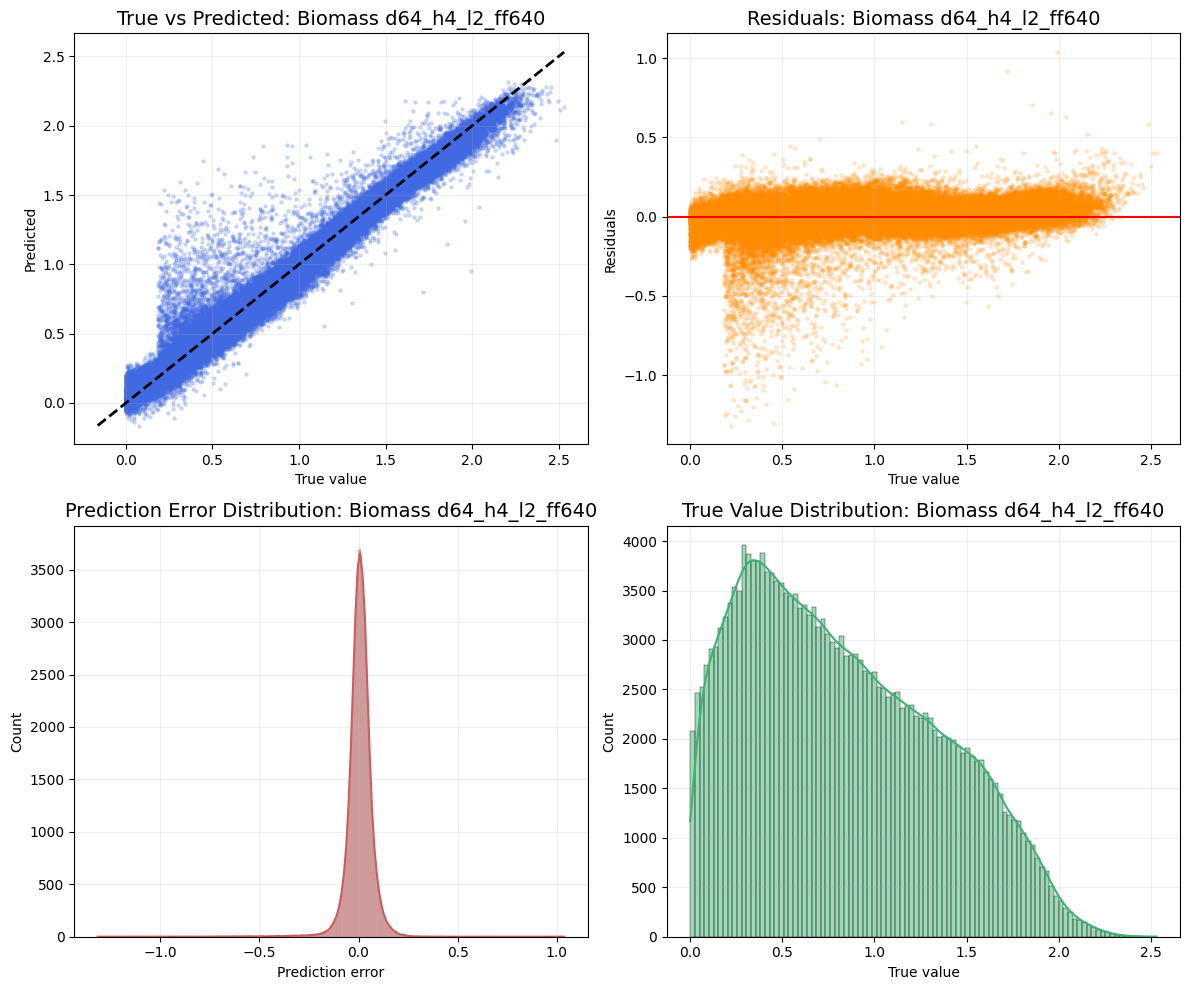

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243


d64_h4_l2_ff640 | overall R2=0.9846 | MAE=0.365587 | RMSE=1.457364 | biomass R2=0.9823
Training d64_h8_l2_ff640
Parameters: 207,702
d64_h8_l2_ff640 | epoch 001/100 | train=2.454875 | val=1.463735 | best=1.463735 @ 1 | no_improve=0 | elapsed=00:03:01
d64_h8_l2_ff640 | epoch 002/100 | train=1.319267 | val=1.003606 | best=1.003606 @ 2 | no_improve=0 | elapsed=00:06:06
d64_h8_l2_ff640 | epoch 003/100 | train=0.971823 | val=0.797057 | best=0.797057 @ 3 | no_improve=0 | elapsed=00:09:13
d64_h8_l2_ff640 | epoch 004/100 | train=0.802342 | val=0.644284 | best=0.644284 @ 4 | no_improve=0 | elapsed=00:12:15
d64_h8_l2_ff640 | epoch 005/100 | train=0.678432 | val=0.522425 | best=0.522425 @ 5 | no_improve=0 | elapsed=00:15:20
d64_h8_l2_ff640 | epoch 006/100 | train=0.588218 | val=0.479607 | best=0.479607 @ 6 | no_improve=0 | elapsed=00:18:24
d64_h8_l2_ff640 | epoch 007/100 | train=0.550853 | val=0.453991 | best=0.453991 @ 7 | no_improve=0 | elapsed=00:21:25
d64_h8_l2_ff640 | epoch 008/100 | train=0.

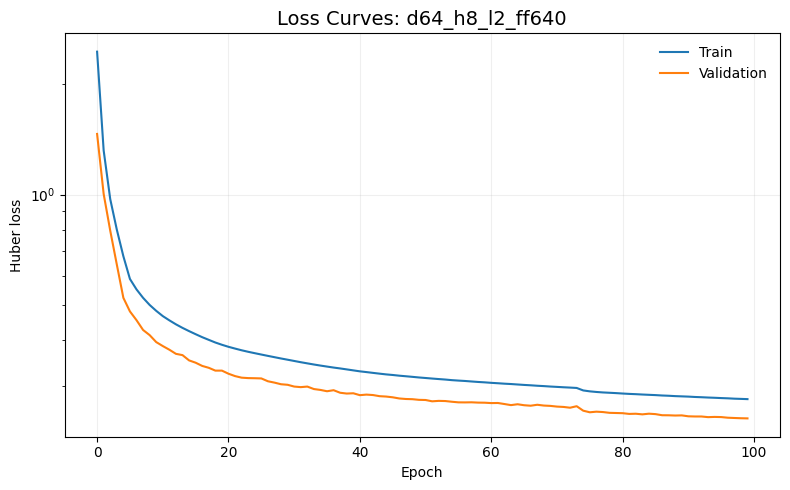

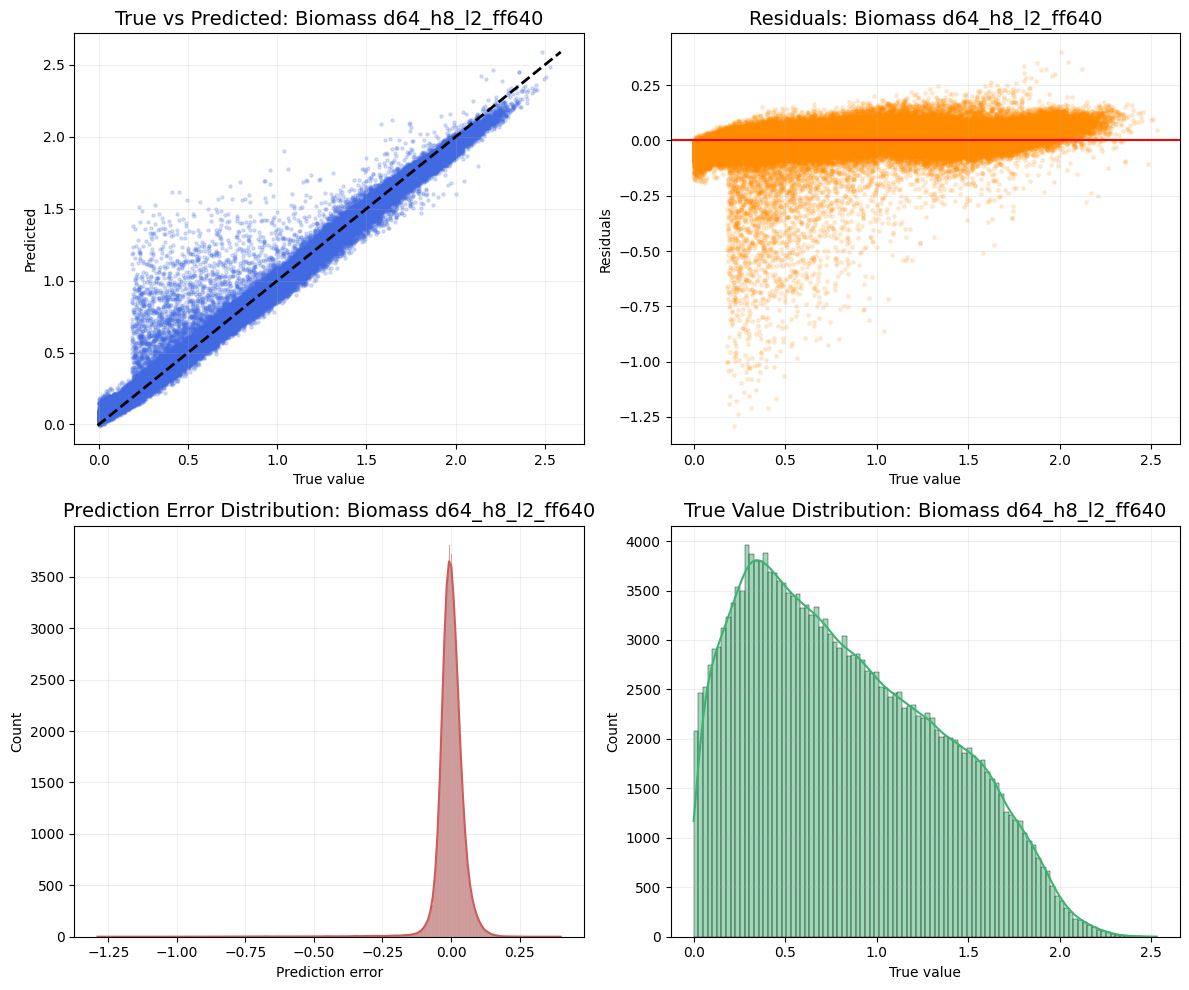

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243
2,d64_h8_l2_ff640,64,8,2,640,207702,100,0.244862,100,19173.036382,0.983394,0.364933,1.512748,0.987445,0.032079,0.058347


d64_h8_l2_ff640 | overall R2=0.9834 | MAE=0.364933 | RMSE=1.512748 | biomass R2=0.9874
Training d64_h8_l3_ff640
Parameters: 308,513
d64_h8_l3_ff640 | epoch 001/100 | train=2.464020 | val=1.128143 | best=1.128143 @ 1 | no_improve=0 | elapsed=00:05:05
d64_h8_l3_ff640 | epoch 002/100 | train=0.986879 | val=0.728808 | best=0.728808 @ 2 | no_improve=0 | elapsed=00:10:13
d64_h8_l3_ff640 | epoch 003/100 | train=0.725558 | val=0.546528 | best=0.546528 @ 3 | no_improve=0 | elapsed=00:15:23
d64_h8_l3_ff640 | epoch 004/100 | train=0.575116 | val=0.435410 | best=0.435410 @ 4 | no_improve=0 | elapsed=00:20:35
d64_h8_l3_ff640 | epoch 005/100 | train=0.493153 | val=0.387289 | best=0.387289 @ 5 | no_improve=0 | elapsed=00:25:42
d64_h8_l3_ff640 | epoch 006/100 | train=0.441598 | val=0.343812 | best=0.343812 @ 6 | no_improve=0 | elapsed=00:30:54
d64_h8_l3_ff640 | epoch 007/100 | train=0.407153 | val=0.318872 | best=0.318872 @ 7 | no_improve=0 | elapsed=00:36:08
d64_h8_l3_ff640 | epoch 008/100 | train=0.

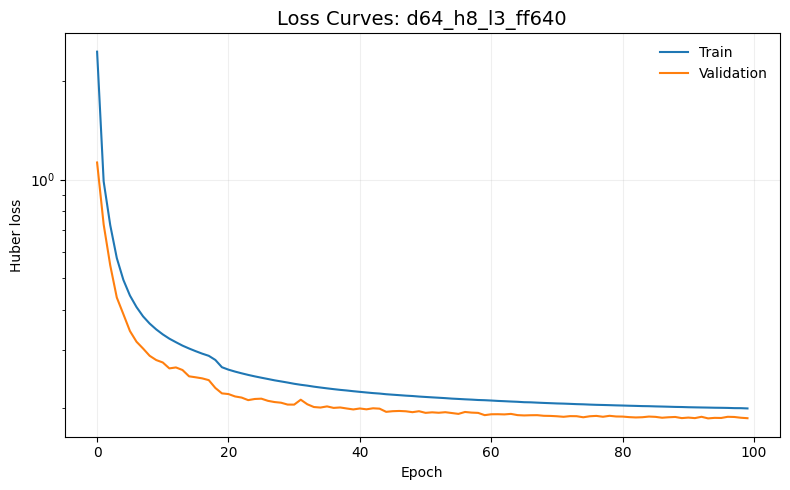

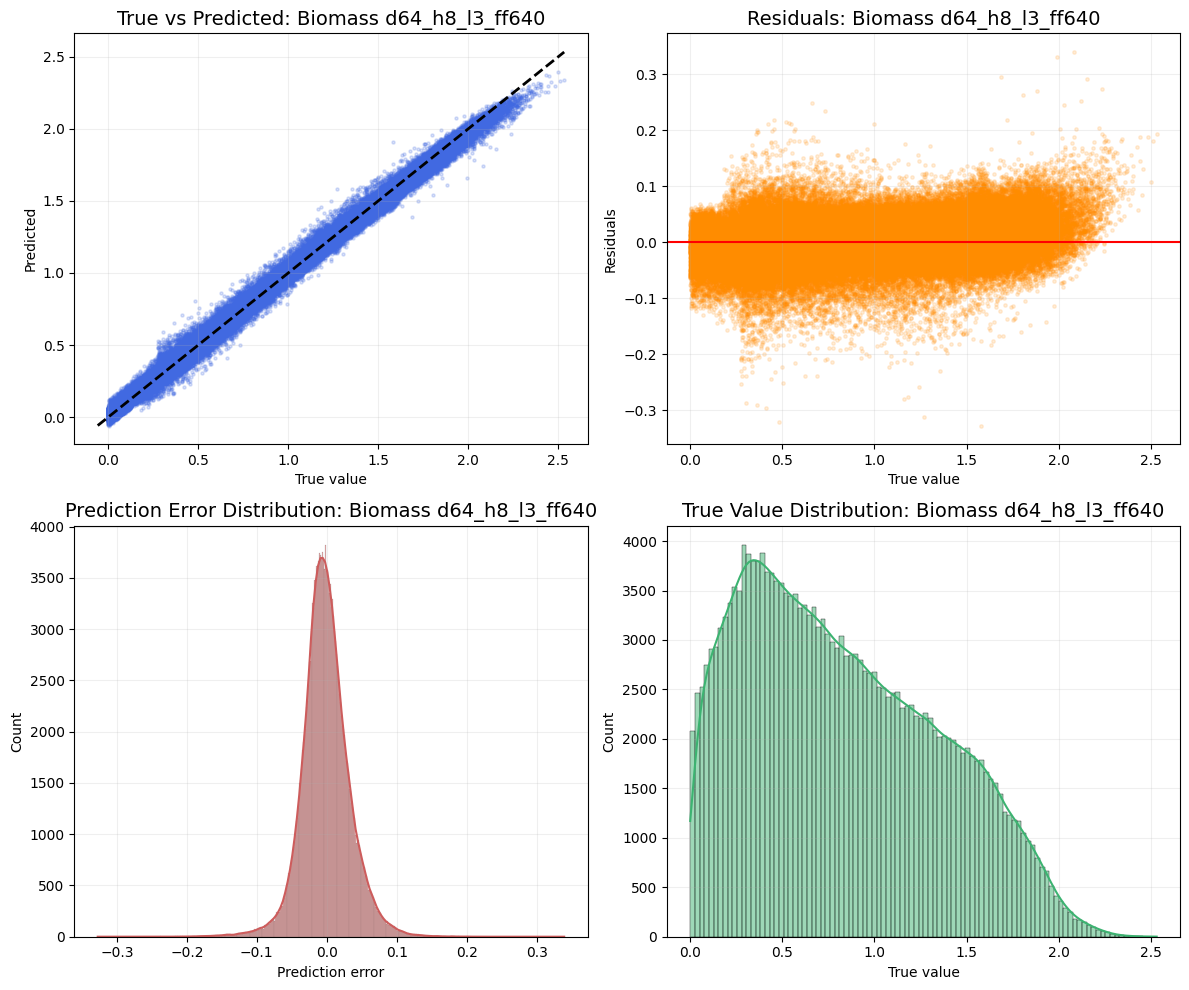

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243
2,d64_h8_l2_ff640,64,8,2,640,207702,100,0.244862,100,19173.036382,0.983394,0.364933,1.512748,0.987445,0.032079,0.058347
3,d64_h8_l3_ff640,64,8,3,640,308513,94,0.185754,100,31827.151992,0.987840,0.271841,1.294525,0.995662,0.025416,0.034295


d64_h8_l3_ff640 | overall R2=0.9878 | MAE=0.271841 | RMSE=1.294525 | biomass R2=0.9957
Training d128_h4_l2_ff640
Parameters: 477,070
d128_h4_l2_ff640 | epoch 001/100 | train=1.824078 | val=0.906775 | best=0.906775 @ 1 | no_improve=0 | elapsed=00:03:49
d128_h4_l2_ff640 | epoch 002/100 | train=0.849717 | val=0.660816 | best=0.660816 @ 2 | no_improve=0 | elapsed=00:07:41
d128_h4_l2_ff640 | epoch 003/100 | train=0.666764 | val=0.528892 | best=0.528892 @ 3 | no_improve=0 | elapsed=00:11:33
d128_h4_l2_ff640 | epoch 004/100 | train=0.577119 | val=0.470040 | best=0.470040 @ 4 | no_improve=0 | elapsed=00:15:27
d128_h4_l2_ff640 | epoch 005/100 | train=0.523687 | val=0.434670 | best=0.434670 @ 5 | no_improve=0 | elapsed=00:19:12
d128_h4_l2_ff640 | epoch 006/100 | train=0.490678 | val=0.405137 | best=0.405137 @ 6 | no_improve=0 | elapsed=00:22:56
d128_h4_l2_ff640 | epoch 007/100 | train=0.462629 | val=0.388973 | best=0.388973 @ 7 | no_improve=0 | elapsed=00:26:25
d128_h4_l2_ff640 | epoch 008/100 |

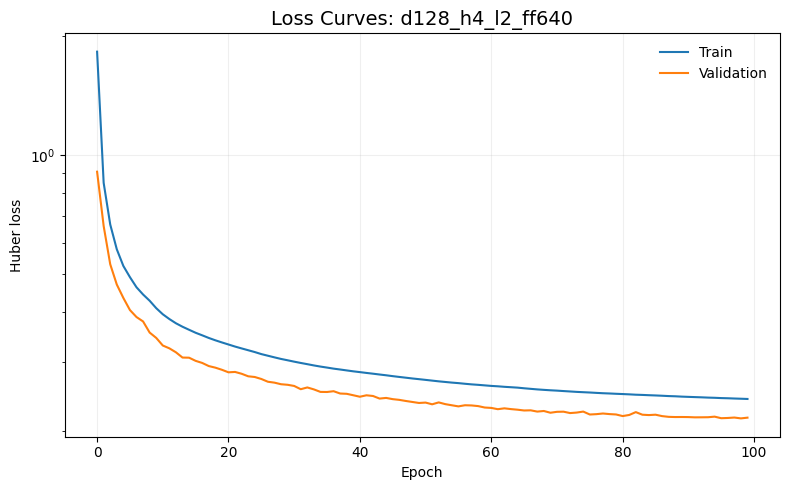

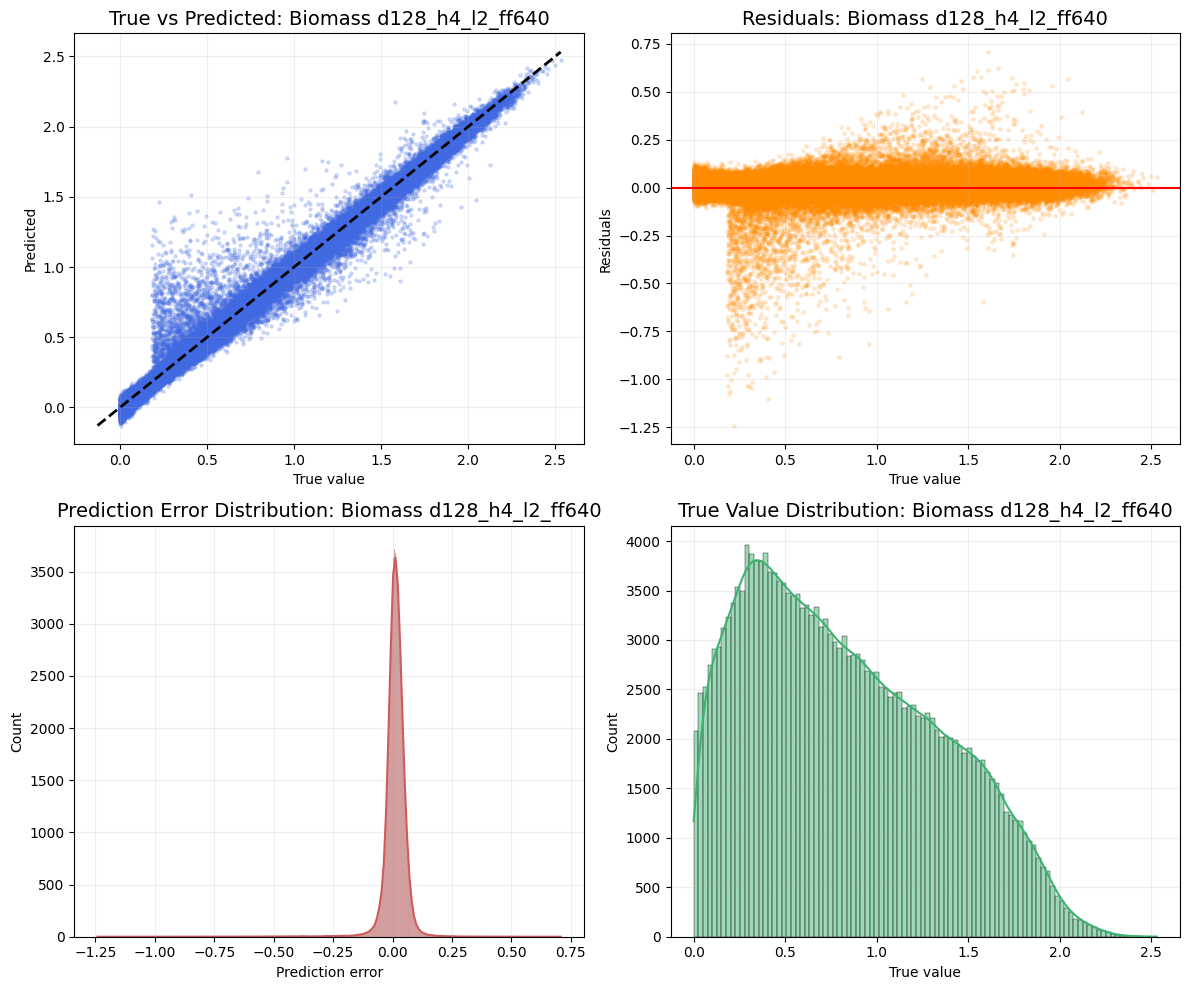

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243
2,d64_h8_l2_ff640,64,8,2,640,207702,100,0.244862,100,19173.036382,0.983394,0.364933,1.512748,0.987445,0.032079,0.058347
3,d64_h8_l3_ff640,64,8,3,640,308513,94,0.185754,100,31827.151992,0.987840,0.271841,1.294525,0.995662,0.025416,0.034295
4,d128_h4_l2_ff640,128,4,2,640,477070,99,0.215609,100,21098.099262,0.986513,0.323324,1.363286,0.989837,0.031036,0.052495


d128_h4_l2_ff640 | overall R2=0.9865 | MAE=0.323324 | RMSE=1.363286 | biomass R2=0.9898
Training d128_h8_l2_ff640
Parameters: 477,078
d128_h8_l2_ff640 | epoch 001/100 | train=1.872433 | val=0.874505 | best=0.874505 @ 1 | no_improve=0 | elapsed=00:04:07
d128_h8_l2_ff640 | epoch 002/100 | train=0.778026 | val=0.569854 | best=0.569854 @ 2 | no_improve=0 | elapsed=00:08:22
d128_h8_l2_ff640 | epoch 003/100 | train=0.593838 | val=0.486329 | best=0.486329 @ 3 | no_improve=0 | elapsed=00:12:36
d128_h8_l2_ff640 | epoch 004/100 | train=0.520059 | val=0.431947 | best=0.431947 @ 4 | no_improve=0 | elapsed=00:16:49
d128_h8_l2_ff640 | epoch 005/100 | train=0.480757 | val=0.397700 | best=0.397700 @ 5 | no_improve=0 | elapsed=00:21:05
d128_h8_l2_ff640 | epoch 006/100 | train=0.451334 | val=0.379198 | best=0.379198 @ 6 | no_improve=0 | elapsed=00:25:17
d128_h8_l2_ff640 | epoch 007/100 | train=0.432165 | val=0.372335 | best=0.372335 @ 7 | no_improve=0 | elapsed=00:29:31
d128_h8_l2_ff640 | epoch 008/100 

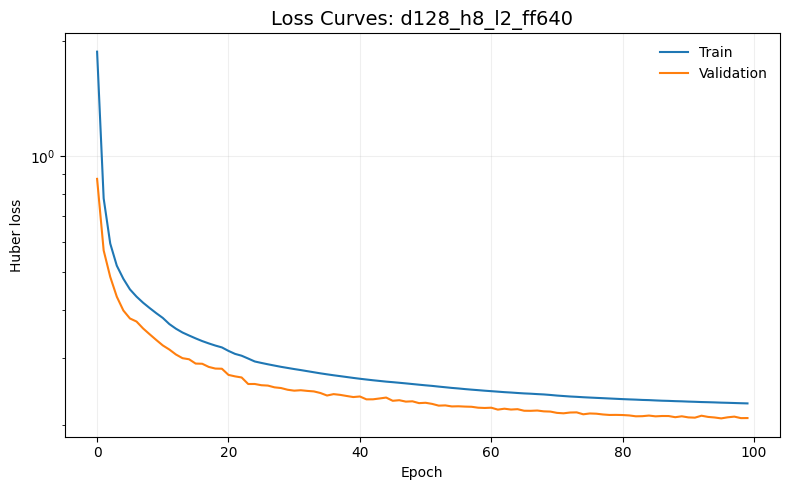

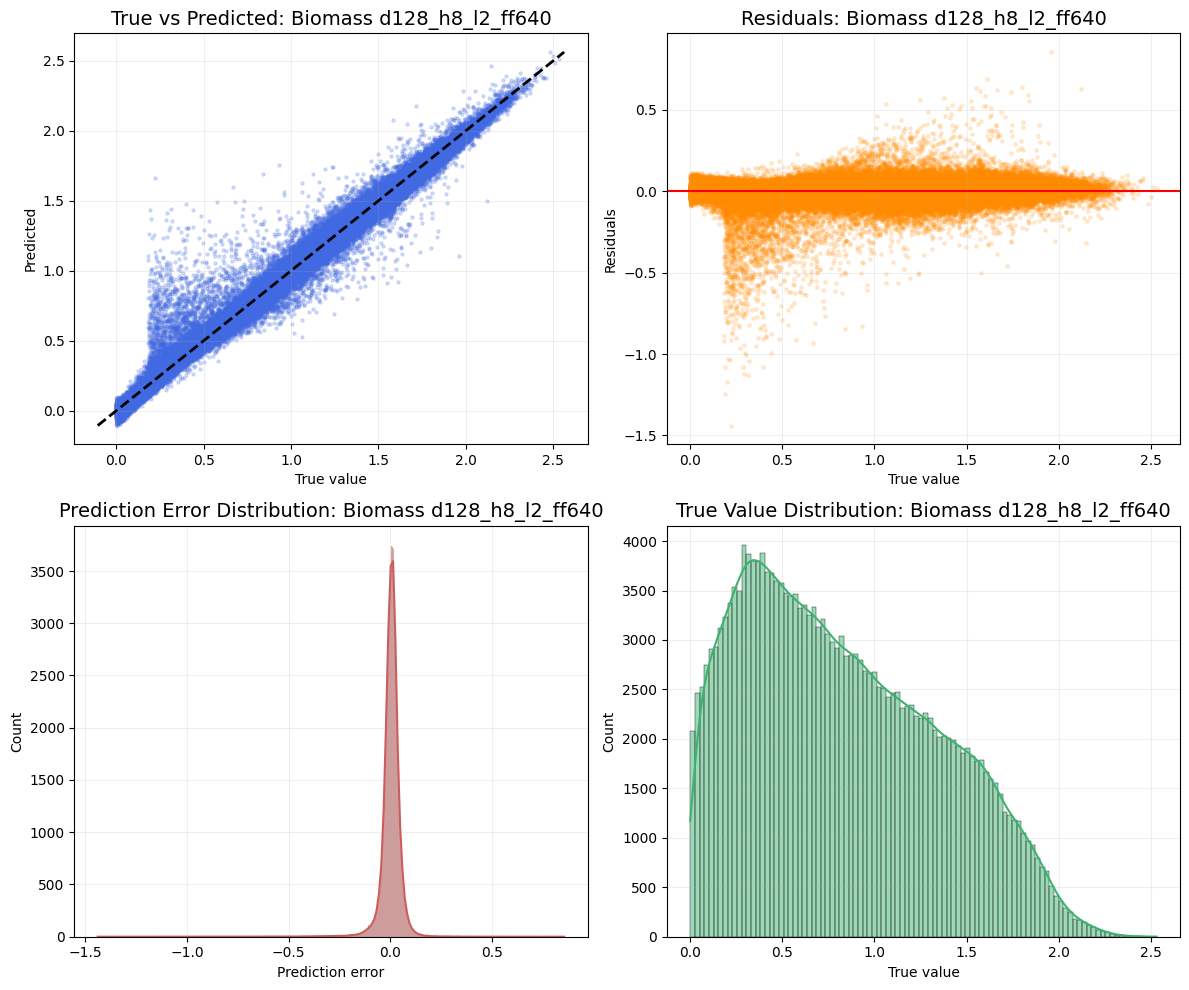

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243
2,d64_h8_l2_ff640,64,8,2,640,207702,100,0.244862,100,19173.036382,0.983394,0.364933,1.512748,0.987445,0.032079,0.058347
3,d64_h8_l3_ff640,64,8,3,640,308513,94,0.185754,100,31827.151992,0.987840,0.271841,1.294525,0.995662,0.025416,0.034295
4,d128_h4_l2_ff640,128,4,2,640,477070,99,0.215609,100,21098.099262,0.986513,0.323324,1.363286,0.989837,0.031036,0.052495
5,d128_h8_l2_ff640,128,8,2,640,477078,96,0.208508,100,24980.327292,0.986615,0.310737,1.358151,0.989475,0.030356,0.053421


d128_h8_l2_ff640 | overall R2=0.9866 | MAE=0.310737 | RMSE=1.358151 | biomass R2=0.9895
Training d128_h8_l3_ff640
Parameters: 709,537
d128_h8_l3_ff640 | epoch 001/100 | train=1.777603 | val=0.707740 | best=0.707740 @ 1 | no_improve=0 | elapsed=00:06:02
d128_h8_l3_ff640 | epoch 002/100 | train=0.576483 | val=0.408239 | best=0.408239 @ 2 | no_improve=0 | elapsed=00:12:10
d128_h8_l3_ff640 | epoch 003/100 | train=0.422846 | val=0.326745 | best=0.326745 @ 3 | no_improve=0 | elapsed=00:18:22
d128_h8_l3_ff640 | epoch 004/100 | train=0.362028 | val=0.286623 | best=0.286623 @ 4 | no_improve=0 | elapsed=00:24:37
d128_h8_l3_ff640 | epoch 005/100 | train=0.325493 | val=0.263111 | best=0.263111 @ 5 | no_improve=0 | elapsed=00:30:51
d128_h8_l3_ff640 | epoch 006/100 | train=0.303024 | val=0.248557 | best=0.248557 @ 6 | no_improve=0 | elapsed=00:37:12
d128_h8_l3_ff640 | epoch 007/100 | train=0.286612 | val=0.243221 | best=0.243221 @ 7 | no_improve=0 | elapsed=00:43:31
d128_h8_l3_ff640 | epoch 008/100 

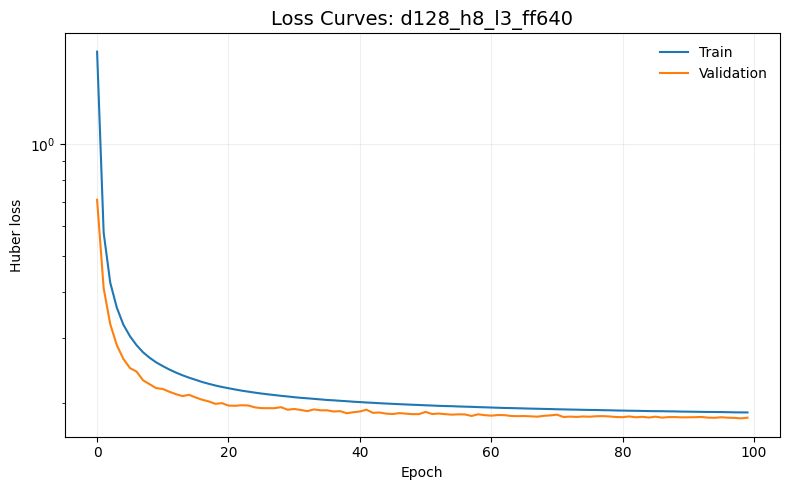

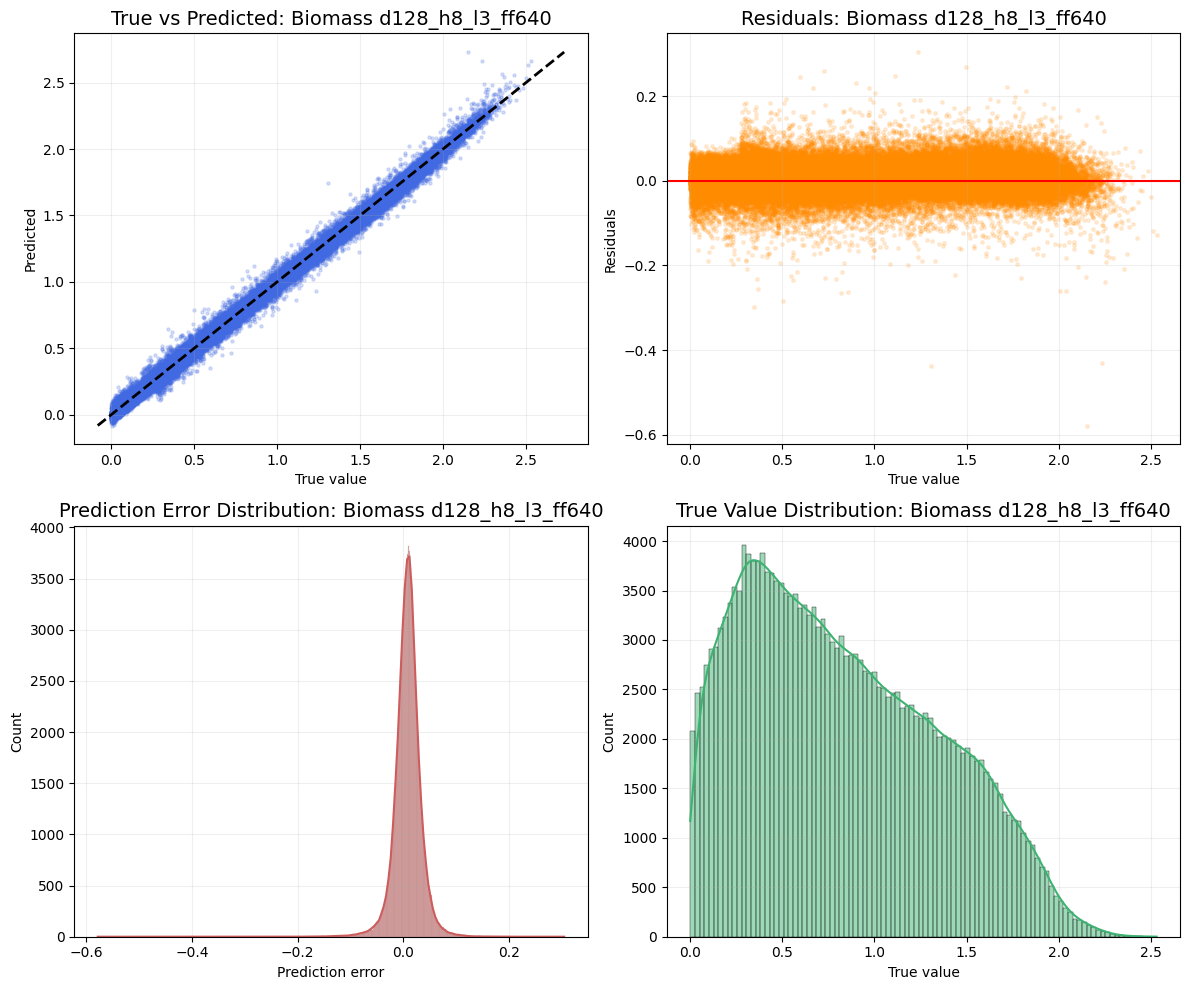

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243
2,d64_h8_l2_ff640,64,8,2,640,207702,100,0.244862,100,19173.036382,0.983394,0.364933,1.512748,0.987445,0.032079,0.058347
3,d64_h8_l3_ff640,64,8,3,640,308513,94,0.185754,100,31827.151992,0.987840,0.271841,1.294525,0.995662,0.025416,0.034295
4,d128_h4_l2_ff640,128,4,2,640,477070,99,0.215609,100,21098.099262,0.986513,0.323324,1.363286,0.989837,0.031036,0.052495
5,d128_h8_l2_ff640,128,8,2,640,477078,96,0.208508,100,24980.327292,0.986615,0.310737,1.358151,0.989475,0.030356,0.053421
6,d128_h8_l3_ff640,128,8,3,640,709537,99,0.181757,100,42335.923380,0.987929,0.260483,1.289760,0.997461,0.019132,0.026238


d128_h8_l3_ff640 | overall R2=0.9879 | MAE=0.260483 | RMSE=1.289760 | biomass R2=0.9975
Training d128_h8_l3_ff1024
Parameters: 1,007,905
d128_h8_l3_ff1024 | epoch 001/100 | train=1.735263 | val=0.745336 | best=0.745336 @ 1 | no_improve=0 | elapsed=00:20:18
d128_h8_l3_ff1024 | epoch 002/100 | train=0.603713 | val=0.425731 | best=0.425731 @ 2 | no_improve=0 | elapsed=00:36:17
d128_h8_l3_ff1024 | epoch 003/100 | train=0.445321 | val=0.347682 | best=0.347682 @ 3 | no_improve=0 | elapsed=00:44:41
d128_h8_l3_ff1024 | epoch 004/100 | train=0.384053 | val=0.304331 | best=0.304331 @ 4 | no_improve=0 | elapsed=00:52:51
d128_h8_l3_ff1024 | epoch 005/100 | train=0.345215 | val=0.280505 | best=0.280505 @ 5 | no_improve=0 | elapsed=01:00:34
d128_h8_l3_ff1024 | epoch 006/100 | train=0.317480 | val=0.264665 | best=0.264665 @ 6 | no_improve=0 | elapsed=01:08:34
d128_h8_l3_ff1024 | epoch 007/100 | train=0.298375 | val=0.251112 | best=0.251112 @ 7 | no_improve=0 | elapsed=01:16:36
d128_h8_l3_ff1024 | epo

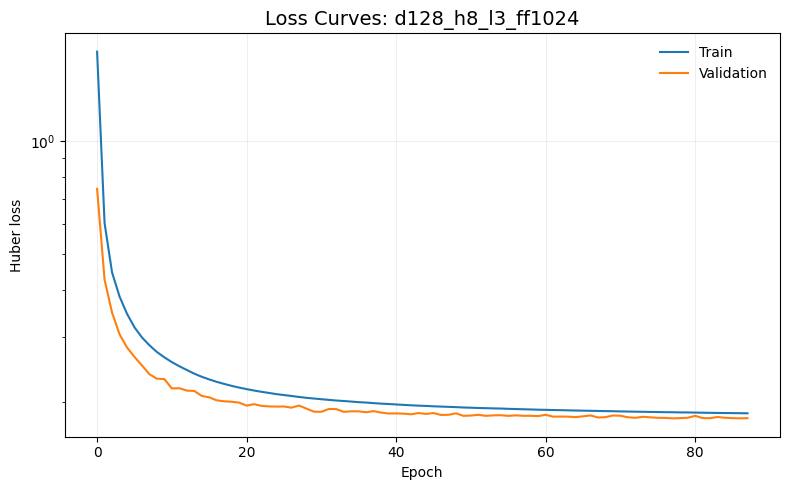

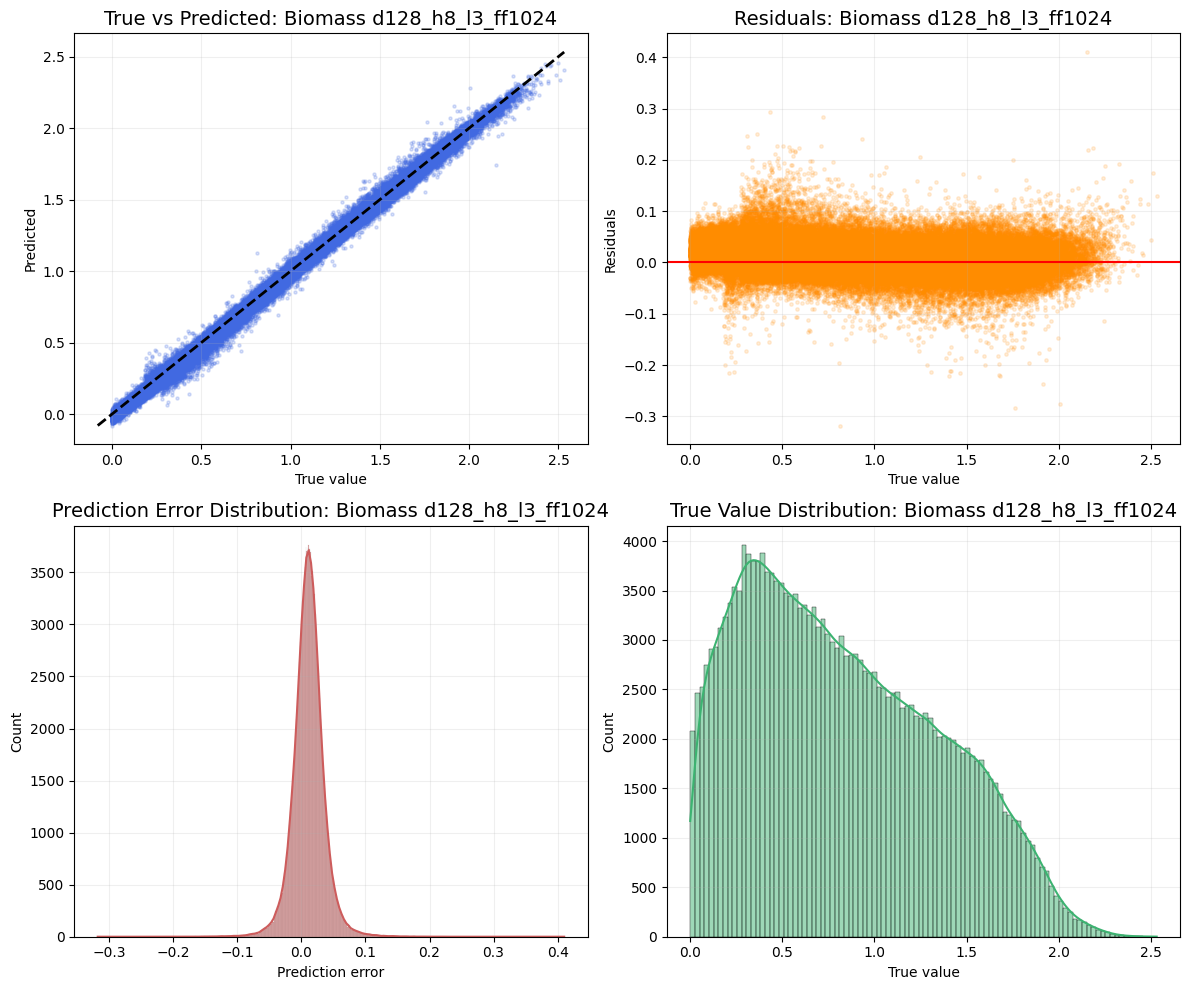

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243
2,d64_h8_l2_ff640,64,8,2,640,207702,100,0.244862,100,19173.036382,0.983394,0.364933,1.512748,0.987445,0.032079,0.058347
3,d64_h8_l3_ff640,64,8,3,640,308513,94,0.185754,100,31827.151992,0.987840,0.271841,1.294525,0.995662,0.025416,0.034295
4,d128_h4_l2_ff640,128,4,2,640,477070,99,0.215609,100,21098.099262,0.986513,0.323324,1.363286,0.989837,0.031036,0.052495
5,d128_h8_l2_ff640,128,8,2,640,477078,96,0.208508,100,24980.327292,0.986615,0.310737,1.358151,0.989475,0.030356,0.053421
6,d128_h8_l3_ff640,128,8,3,640,709537,99,0.181757,100,42335.923380,0.987929,0.260483,1.289760,0.997461,0.019132,0.026238
7,d128_h8_l3_ff1024,128,8,3,1024,1007905,78,0.181181,88,41554.740394,0.988028,0.258802,1.284443,0.997312,0.020160,0.026998


d128_h8_l3_ff1024 | overall R2=0.9880 | MAE=0.258802 | RMSE=1.284443 | biomass R2=0.9973
Training d256_h4_l2_ff640
Parameters: 1,212,430
d256_h4_l2_ff640 | epoch 001/100 | train=1.496802 | val=0.729018 | best=0.729018 @ 1 | no_improve=0 | elapsed=00:06:02
d256_h4_l2_ff640 | epoch 002/100 | train=0.688917 | val=0.541567 | best=0.541567 @ 2 | no_improve=0 | elapsed=00:12:05
d256_h4_l2_ff640 | epoch 003/100 | train=0.564160 | val=0.454396 | best=0.454396 @ 3 | no_improve=0 | elapsed=00:18:08
d256_h4_l2_ff640 | epoch 004/100 | train=0.495868 | val=0.414814 | best=0.414814 @ 4 | no_improve=0 | elapsed=00:24:02
d256_h4_l2_ff640 | epoch 005/100 | train=0.456646 | val=0.394328 | best=0.394328 @ 5 | no_improve=0 | elapsed=00:30:04
d256_h4_l2_ff640 | epoch 006/100 | train=0.427590 | val=0.355729 | best=0.355729 @ 6 | no_improve=0 | elapsed=00:36:06
d256_h4_l2_ff640 | epoch 007/100 | train=0.400812 | val=0.339921 | best=0.339921 @ 7 | no_improve=0 | elapsed=00:42:06
d256_h4_l2_ff640 | epoch 008/1

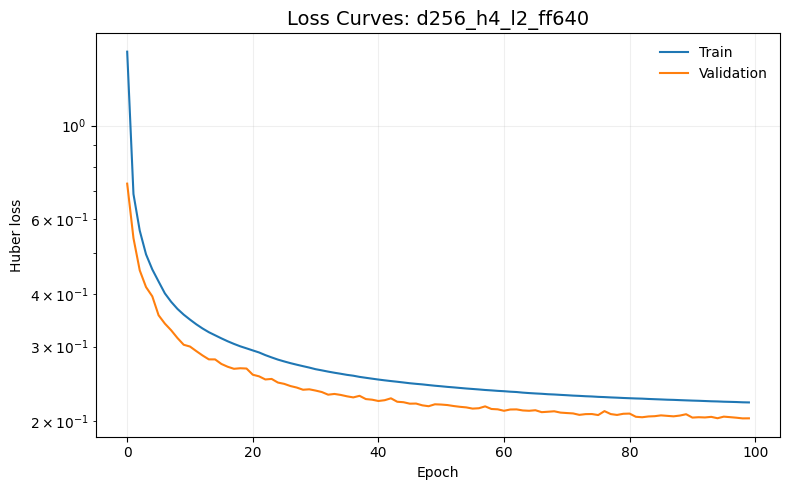

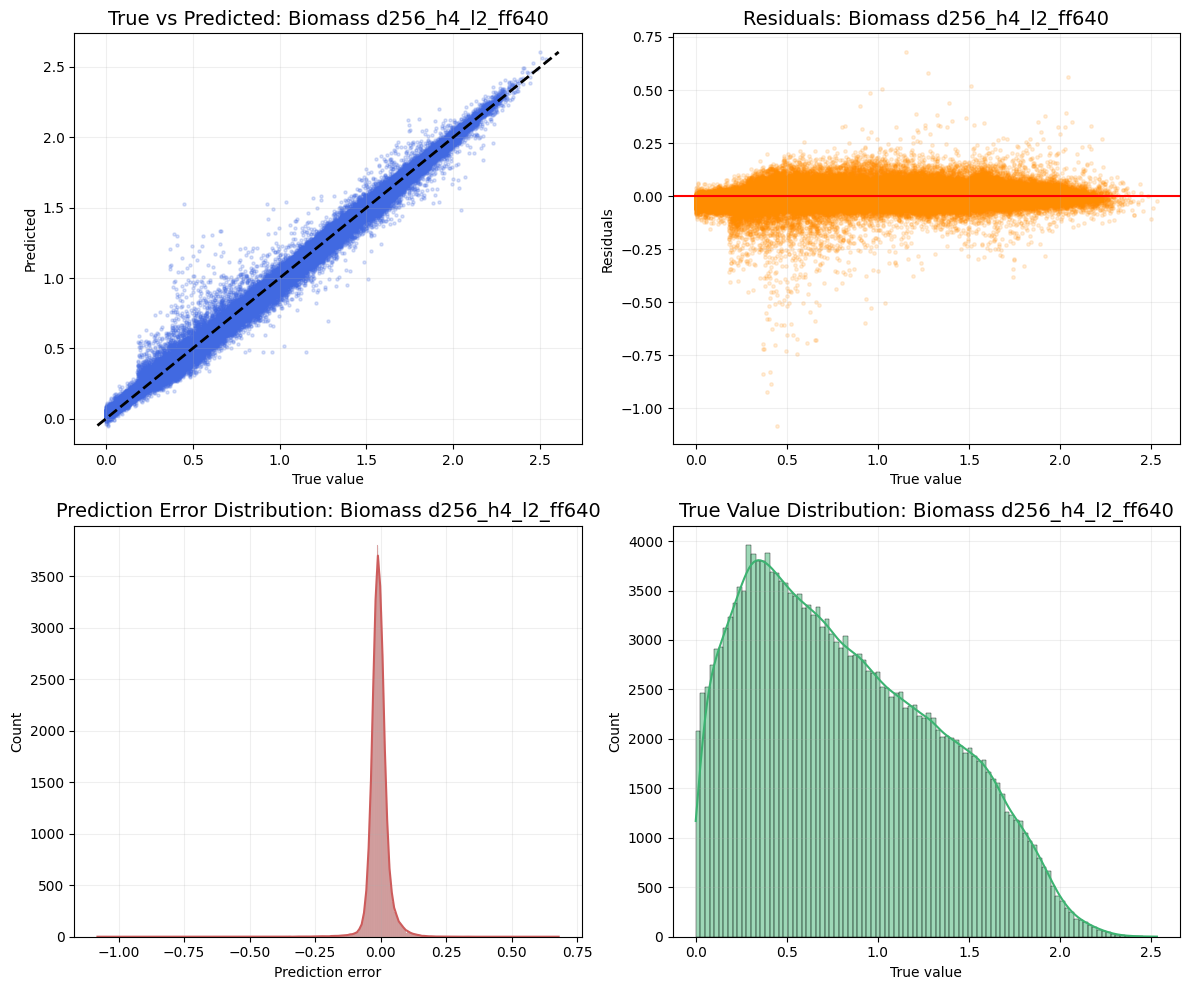

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243
2,d64_h8_l2_ff640,64,8,2,640,207702,100,0.244862,100,19173.036382,0.983394,0.364933,1.512748,0.987445,0.032079,0.058347
3,d64_h8_l3_ff640,64,8,3,640,308513,94,0.185754,100,31827.151992,0.987840,0.271841,1.294525,0.995662,0.025416,0.034295
4,d128_h4_l2_ff640,128,4,2,640,477070,99,0.215609,100,21098.099262,0.986513,0.323324,1.363286,0.989837,0.031036,0.052495
5,d128_h8_l2_ff640,128,8,2,640,477078,96,0.208508,100,24980.327292,0.986615,0.310737,1.358151,0.989475,0.030356,0.053421
6,d128_h8_l3_ff640,128,8,3,640,709537,99,0.181757,100,42335.923380,0.987929,0.260483,1.289760,0.997461,0.019132,0.026238
7,d128_h8_l3_ff1024,128,8,3,1024,1007905,78,0.181181,88,41554.740394,0.988028,0.258802,1.284443,0.997312,0.020160,0.026998
8,d256_h4_l2_ff640,256,4,2,640,1212430,99,0.202750,100,40865.228697,0.987456,0.304674,1.314784,0.995184,0.023678,0.036138


d256_h4_l2_ff640 | overall R2=0.9875 | MAE=0.304674 | RMSE=1.314784 | biomass R2=0.9952
Training d256_h8_l3_ff640
Parameters: 1,806,497
d256_h8_l3_ff640 | epoch 001/100 | train=1.355035 | val=0.496639 | best=0.496639 @ 1 | no_improve=0 | elapsed=00:09:55
d256_h8_l3_ff640 | epoch 002/100 | train=0.470343 | val=0.353444 | best=0.353444 @ 2 | no_improve=0 | elapsed=00:19:58
d256_h8_l3_ff640 | epoch 003/100 | train=0.375428 | val=0.302513 | best=0.302513 @ 3 | no_improve=0 | elapsed=00:29:57
d256_h8_l3_ff640 | epoch 004/100 | train=0.325907 | val=0.265627 | best=0.265627 @ 4 | no_improve=0 | elapsed=00:39:59
d256_h8_l3_ff640 | epoch 005/100 | train=0.294151 | val=0.246578 | best=0.246578 @ 5 | no_improve=0 | elapsed=00:49:57
d256_h8_l3_ff640 | epoch 006/100 | train=0.274668 | val=0.236059 | best=0.236059 @ 6 | no_improve=0 | elapsed=00:59:46
d256_h8_l3_ff640 | epoch 007/100 | train=0.260877 | val=0.229080 | best=0.229080 @ 7 | no_improve=0 | elapsed=01:09:57
d256_h8_l3_ff640 | epoch 008/10

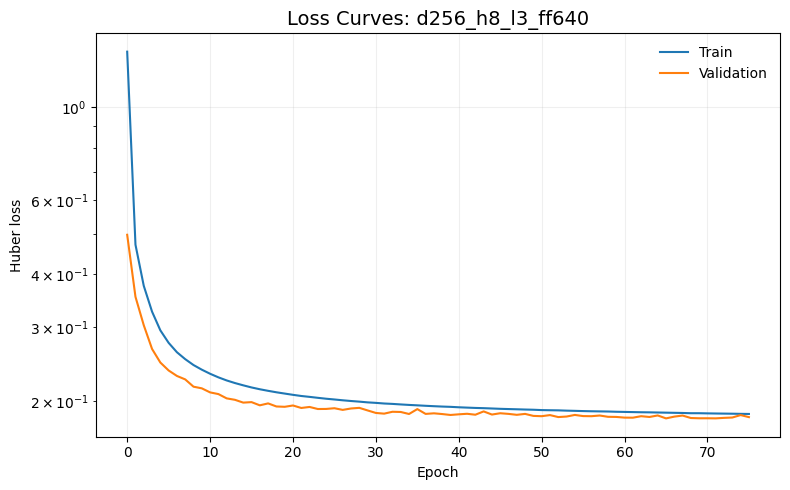

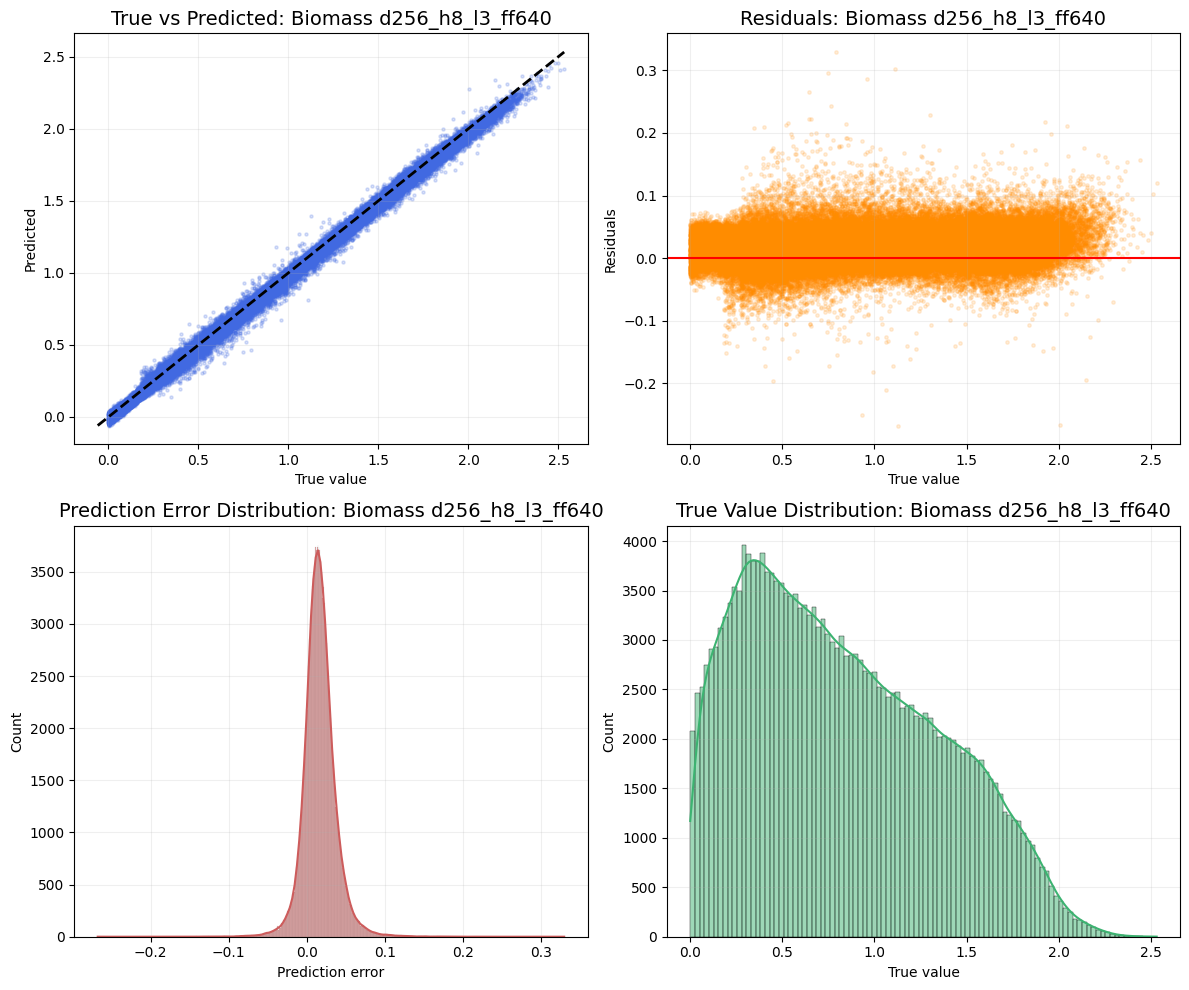

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243
2,d64_h8_l2_ff640,64,8,2,640,207702,100,0.244862,100,19173.036382,0.983394,0.364933,1.512748,0.987445,0.032079,0.058347
3,d64_h8_l3_ff640,64,8,3,640,308513,94,0.185754,100,31827.151992,0.987840,0.271841,1.294525,0.995662,0.025416,0.034295
4,d128_h4_l2_ff640,128,4,2,640,477070,99,0.215609,100,21098.099262,0.986513,0.323324,1.363286,0.989837,0.031036,0.052495
5,d128_h8_l2_ff640,128,8,2,640,477078,96,0.208508,100,24980.327292,0.986615,0.310737,1.358151,0.989475,0.030356,0.053421
6,d128_h8_l3_ff640,128,8,3,640,709537,99,0.181757,100,42335.923380,0.987929,0.260483,1.289760,0.997461,0.019132,0.026238
7,d128_h8_l3_ff1024,128,8,3,1024,1007905,78,0.181181,88,41554.740394,0.988028,0.258802,1.284443,0.997312,0.020160,0.026998
8,d256_h4_l2_ff640,256,4,2,640,1212430,99,0.202750,100,40865.228697,0.987456,0.304674,1.314784,0.995184,0.023678,0.036138
9,d256_h8_l3_ff640,256,8,3,640,1806497,66,0.181536,76,43950.335704,0.987878,0.257657,1.292482,0.997427,0.020373,0.026413


d256_h8_l3_ff640 | overall R2=0.9879 | MAE=0.257657 | RMSE=1.292482 | biomass R2=0.9974
Training d256_h8_l3_ff1024
Parameters: 2,399,777
d256_h8_l3_ff1024 | epoch 001/100 | train=1.301014 | val=0.476183 | best=0.476183 @ 1 | no_improve=0 | elapsed=00:10:05
d256_h8_l3_ff1024 | epoch 002/100 | train=0.458294 | val=0.333898 | best=0.333898 @ 2 | no_improve=0 | elapsed=00:20:16
d256_h8_l3_ff1024 | epoch 003/100 | train=0.373607 | val=0.297246 | best=0.297246 @ 3 | no_improve=0 | elapsed=00:30:20
d256_h8_l3_ff1024 | epoch 004/100 | train=0.329315 | val=0.260800 | best=0.260800 @ 4 | no_improve=0 | elapsed=00:40:25
d256_h8_l3_ff1024 | epoch 005/100 | train=0.296177 | val=0.241397 | best=0.241397 @ 5 | no_improve=0 | elapsed=00:50:30
d256_h8_l3_ff1024 | epoch 006/100 | train=0.275915 | val=0.227777 | best=0.227777 @ 6 | no_improve=0 | elapsed=01:00:33
d256_h8_l3_ff1024 | epoch 007/100 | train=0.261250 | val=0.225316 | best=0.225316 @ 7 | no_improve=0 | elapsed=01:10:35
d256_h8_l3_ff1024 | epo

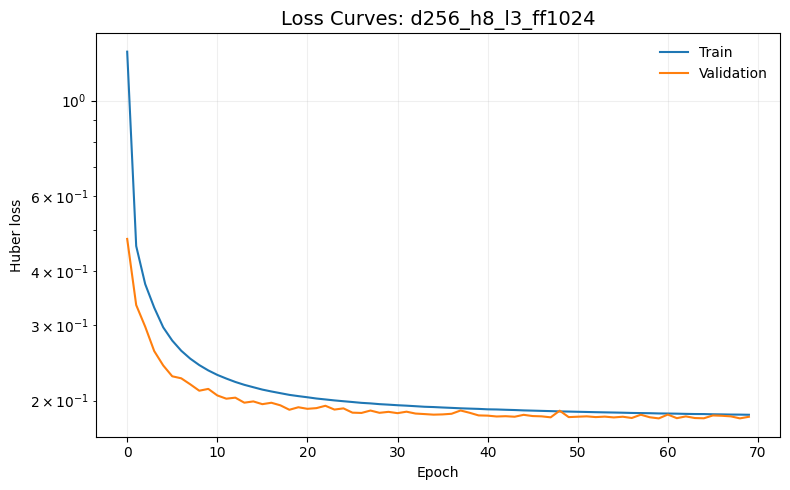

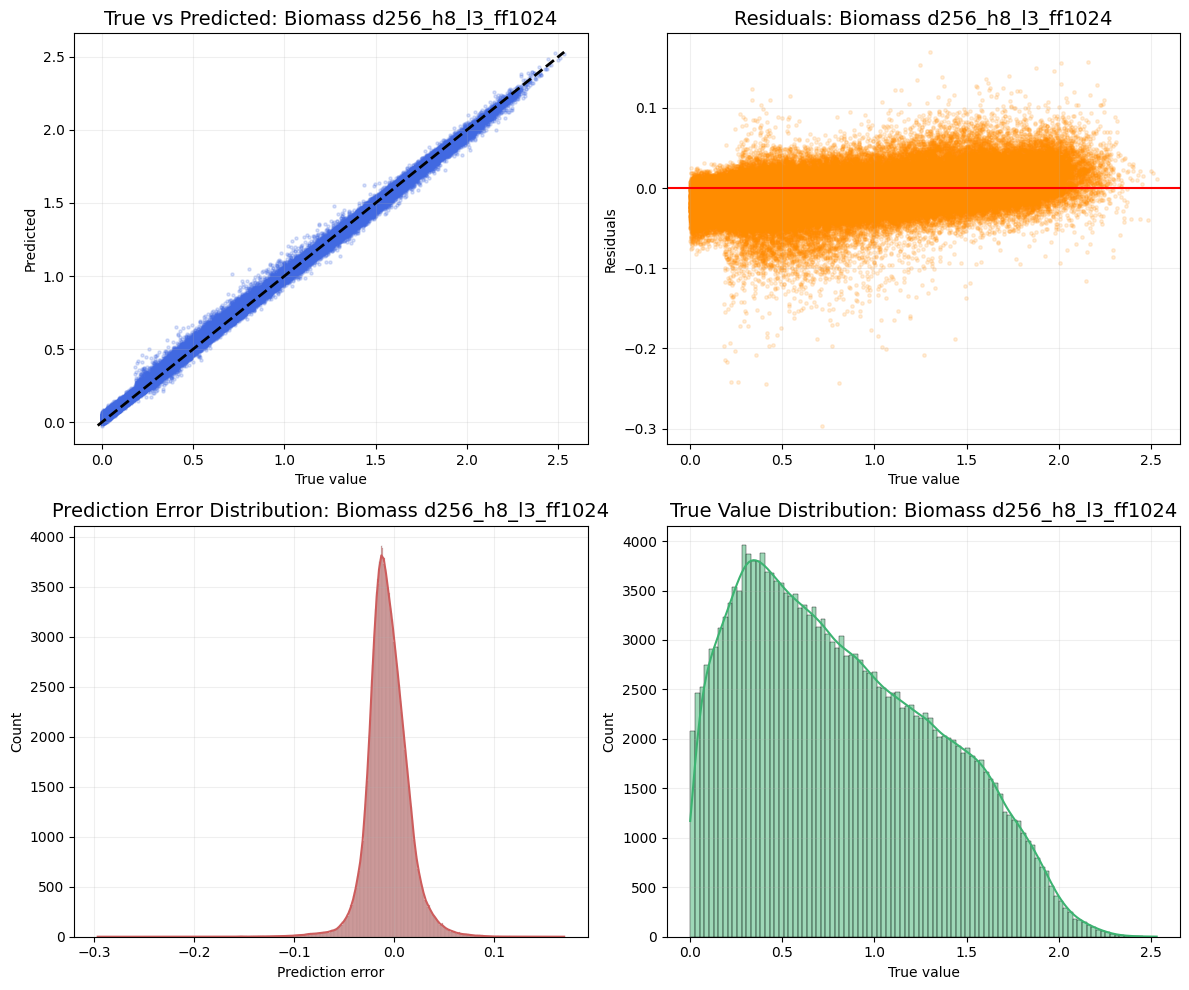

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243
2,d64_h8_l2_ff640,64,8,2,640,207702,100,0.244862,100,19173.036382,0.983394,0.364933,1.512748,0.987445,0.032079,0.058347
3,d64_h8_l3_ff640,64,8,3,640,308513,94,0.185754,100,31827.151992,0.987840,0.271841,1.294525,0.995662,0.025416,0.034295
4,d128_h4_l2_ff640,128,4,2,640,477070,99,0.215609,100,21098.099262,0.986513,0.323324,1.363286,0.989837,0.031036,0.052495
5,d128_h8_l2_ff640,128,8,2,640,477078,96,0.208508,100,24980.327292,0.986615,0.310737,1.358151,0.989475,0.030356,0.053421
6,d128_h8_l3_ff640,128,8,3,640,709537,99,0.181757,100,42335.923380,0.987929,0.260483,1.289760,0.997461,0.019132,0.026238
7,d128_h8_l3_ff1024,128,8,3,1024,1007905,78,0.181181,88,41554.740394,0.988028,0.258802,1.284443,0.997312,0.020160,0.026998
8,d256_h4_l2_ff640,256,4,2,640,1212430,99,0.202750,100,40865.228697,0.987456,0.304674,1.314784,0.995184,0.023678,0.036138
9,d256_h8_l3_ff640,256,8,3,640,1806497,66,0.181536,76,43950.335704,0.987878,0.257657,1.292482,0.997427,0.020373,0.026413


d256_h8_l3_ff1024 | overall R2=0.9879 | MAE=0.261602 | RMSE=1.291479 | biomass R2=0.9983
Training d256_h8_l4_ff1024
Parameters: 3,191,596
d256_h8_l4_ff1024 | epoch 001/100 | train=1.338791 | val=0.396931 | best=0.396931 @ 1 | no_improve=0 | elapsed=00:16:11
d256_h8_l4_ff1024 | epoch 002/100 | train=0.393657 | val=0.286900 | best=0.286900 @ 2 | no_improve=0 | elapsed=00:32:25
d256_h8_l4_ff1024 | epoch 003/100 | train=0.317826 | val=0.260753 | best=0.260753 @ 3 | no_improve=0 | elapsed=00:48:42
d256_h8_l4_ff1024 | epoch 004/100 | train=0.278455 | val=0.234985 | best=0.234985 @ 4 | no_improve=0 | elapsed=01:04:52
d256_h8_l4_ff1024 | epoch 005/100 | train=0.256759 | val=0.221859 | best=0.221859 @ 5 | no_improve=0 | elapsed=01:20:36
d256_h8_l4_ff1024 | epoch 006/100 | train=0.242055 | val=0.217251 | best=0.217251 @ 6 | no_improve=0 | elapsed=01:36:12
d256_h8_l4_ff1024 | epoch 007/100 | train=0.231880 | val=0.209204 | best=0.209204 @ 7 | no_improve=0 | elapsed=01:51:57
d256_h8_l4_ff1024 | ep

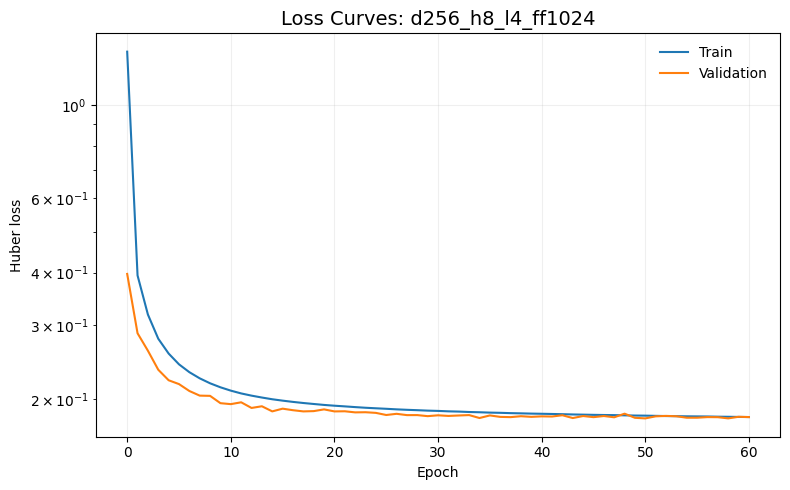

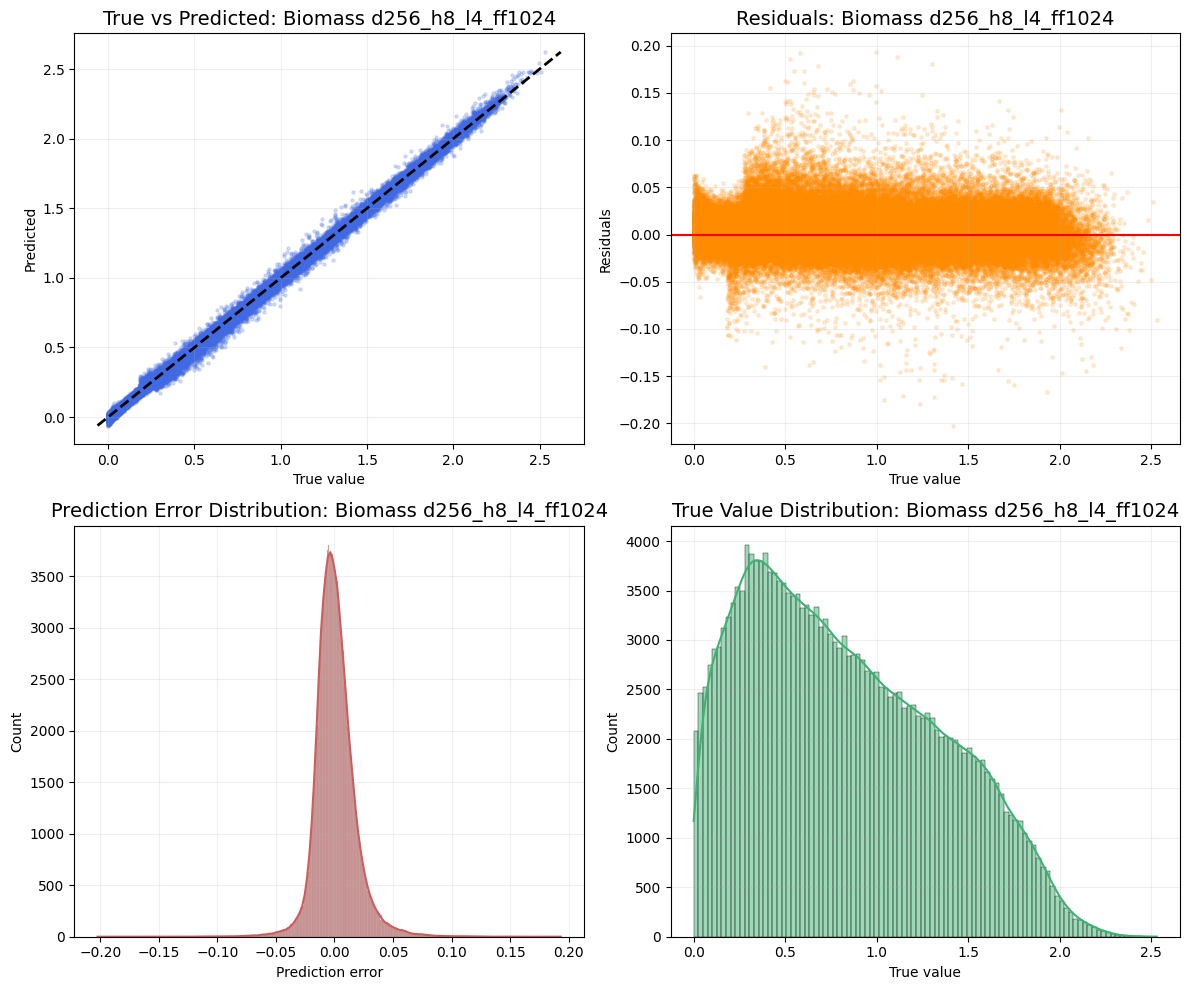

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,99,0.309853,100,11356.492384,0.973446,0.453076,1.912937,0.971424,0.058407,0.088024
1,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.984588,0.365587,1.457364,0.982318,0.042977,0.069243
2,d64_h8_l2_ff640,64,8,2,640,207702,100,0.244862,100,19173.036382,0.983394,0.364933,1.512748,0.987445,0.032079,0.058347
3,d64_h8_l3_ff640,64,8,3,640,308513,94,0.185754,100,31827.151992,0.987840,0.271841,1.294525,0.995662,0.025416,0.034295
4,d128_h4_l2_ff640,128,4,2,640,477070,99,0.215609,100,21098.099262,0.986513,0.323324,1.363286,0.989837,0.031036,0.052495
5,d128_h8_l2_ff640,128,8,2,640,477078,96,0.208508,100,24980.327292,0.986615,0.310737,1.358151,0.989475,0.030356,0.053421
6,d128_h8_l3_ff640,128,8,3,640,709537,99,0.181757,100,42335.923380,0.987929,0.260483,1.289760,0.997461,0.019132,0.026238
7,d128_h8_l3_ff1024,128,8,3,1024,1007905,78,0.181181,88,41554.740394,0.988028,0.258802,1.284443,0.997312,0.020160,0.026998
8,d256_h4_l2_ff640,256,4,2,640,1212430,99,0.202750,100,40865.228697,0.987456,0.304674,1.314784,0.995184,0.023678,0.036138
9,d256_h8_l3_ff640,256,8,3,640,1806497,66,0.181536,76,43950.335704,0.987878,0.257657,1.292482,0.997427,0.020373,0.026413


d256_h8_l4_ff1024 | overall R2=0.9878 | MAE=0.254647 | RMSE=1.295055 | biomass R2=0.9989
Architecture sweep complete. Run the final cells to save combined comparison outputs.


In [6]:
sweep_results = []
trained_models = {}
biomass_panels = {}

for config in MODEL_CONFIGS:
    model, meta = train_model_config(config)
    plot_loss_curves(meta["train_losses"], meta["test_losses"], config)
    metrics, biomass_true, biomass_pred = predict_and_score(model, config)
    plot_biomass_diagnostics(biomass_true, biomass_pred, config)
    biomass_panels[config["name"]] = {
        "true": biomass_true.astype(np.float32, copy=True),
        "pred": biomass_pred.astype(np.float32, copy=True),
    }

    row = {
        **config,
        "n_params": model_param_count(model),
        "best_epoch": meta["best_epoch"],
        "best_val_loss": meta["best_val_loss"],
        "epochs_ran": meta["epochs_ran"],
        "elapsed_sec": meta["elapsed_sec"],
        **metrics,
    }
    sweep_results.append(row)

    current_df = pd.DataFrame(sweep_results)
    display(current_df)

    print(
        f"{config['name']} | overall R2={metrics['overall_r2']:.4f} | "
        f"MAE={metrics['overall_mae']:.6f} | RMSE={metrics['overall_rmse']:.6f} | "
        f"biomass R2={metrics['biomass_r2']:.4f}"
    )

    if KEEP_MODELS:
        trained_models[config["name"]] = model.to("cpu")
    else:
        del model
    del biomass_true, biomass_pred
    empty_cache()
    gc.collect()

print("Architecture sweep complete. Run the final cells to save combined comparison outputs.")

## Model Size Comparison

In [7]:
comparison_cols = [
    "name", "d_model", "n_heads", "n_layers", "d_ff", "n_params",
    "best_epoch", "best_val_loss", "epochs_ran", "elapsed_sec",
    "biomass_r2", "biomass_mae", "biomass_rmse",
    "overall_r2", "overall_mae", "overall_rmse",
]

try:
    comparison_df = pd.DataFrame(sweep_results)
except NameError:
    comparison_df = pd.DataFrame()

if comparison_df.empty and RESULTS_CSV.exists():
    comparison_df = pd.read_csv(RESULTS_CSV)

if comparison_df.empty:
    print("No sweep results available yet. Run the architecture sweep cell first.")
else:
    comparison_df = comparison_df[comparison_cols]
    comparison_df = comparison_df.sort_values("overall_r2", ascending=False).reset_index(drop=True)
    display(comparison_df)
    comparison_df.to_csv(RESULTS_CSV, index=False)
    print(f"Saved final comparison metrics to {RESULTS_CSV}")

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,biomass_r2,biomass_mae,biomass_rmse,overall_r2,overall_mae,overall_rmse
0,d128_h8_l3_ff1024,128,8,3,1024,1007905,78,0.181181,88,41554.740394,0.997312,0.020160,0.026998,0.988028,0.258802,1.284443
1,d128_h8_l3_ff640,128,8,3,640,709537,99,0.181757,100,42335.923380,0.997461,0.019132,0.026238,0.987929,0.260483,1.289760
2,d256_h8_l3_ff1024,256,8,3,1024,2399777,60,0.181706,70,53525.809136,0.998328,0.016062,0.021290,0.987897,0.261602,1.291479
3,d256_h8_l3_ff640,256,8,3,640,1806497,66,0.181536,76,43950.335704,0.997427,0.020373,0.026413,0.987878,0.257657,1.292482
4,d64_h8_l3_ff640,64,8,3,640,308513,94,0.185754,100,31827.151992,0.995662,0.025416,0.034295,0.987840,0.271841,1.294525
5,d256_h8_l4_ff1024,256,8,4,1024,3191596,51,0.180092,61,57303.542676,0.998900,0.012179,0.017267,0.987830,0.254647,1.295055
6,d256_h4_l2_ff640,256,4,2,640,1212430,99,0.202750,100,40865.228697,0.995184,0.023678,0.036138,0.987456,0.304674,1.314784
7,d128_h8_l2_ff640,128,8,2,640,477078,96,0.208508,100,24980.327292,0.989475,0.030356,0.053421,0.986615,0.310737,1.358151
8,d128_h4_l2_ff640,128,4,2,640,477070,99,0.215609,100,21098.099262,0.989837,0.031036,0.052495,0.986513,0.323324,1.363286
9,d64_h4_l2_ff640,64,4,2,640,207694,100,0.242287,100,14820.303796,0.982318,0.042977,0.069243,0.984588,0.365587,1.457364


Saved final comparison metrics to insights\ecoli_core_architecture_sweep\model_size_comparison.csv


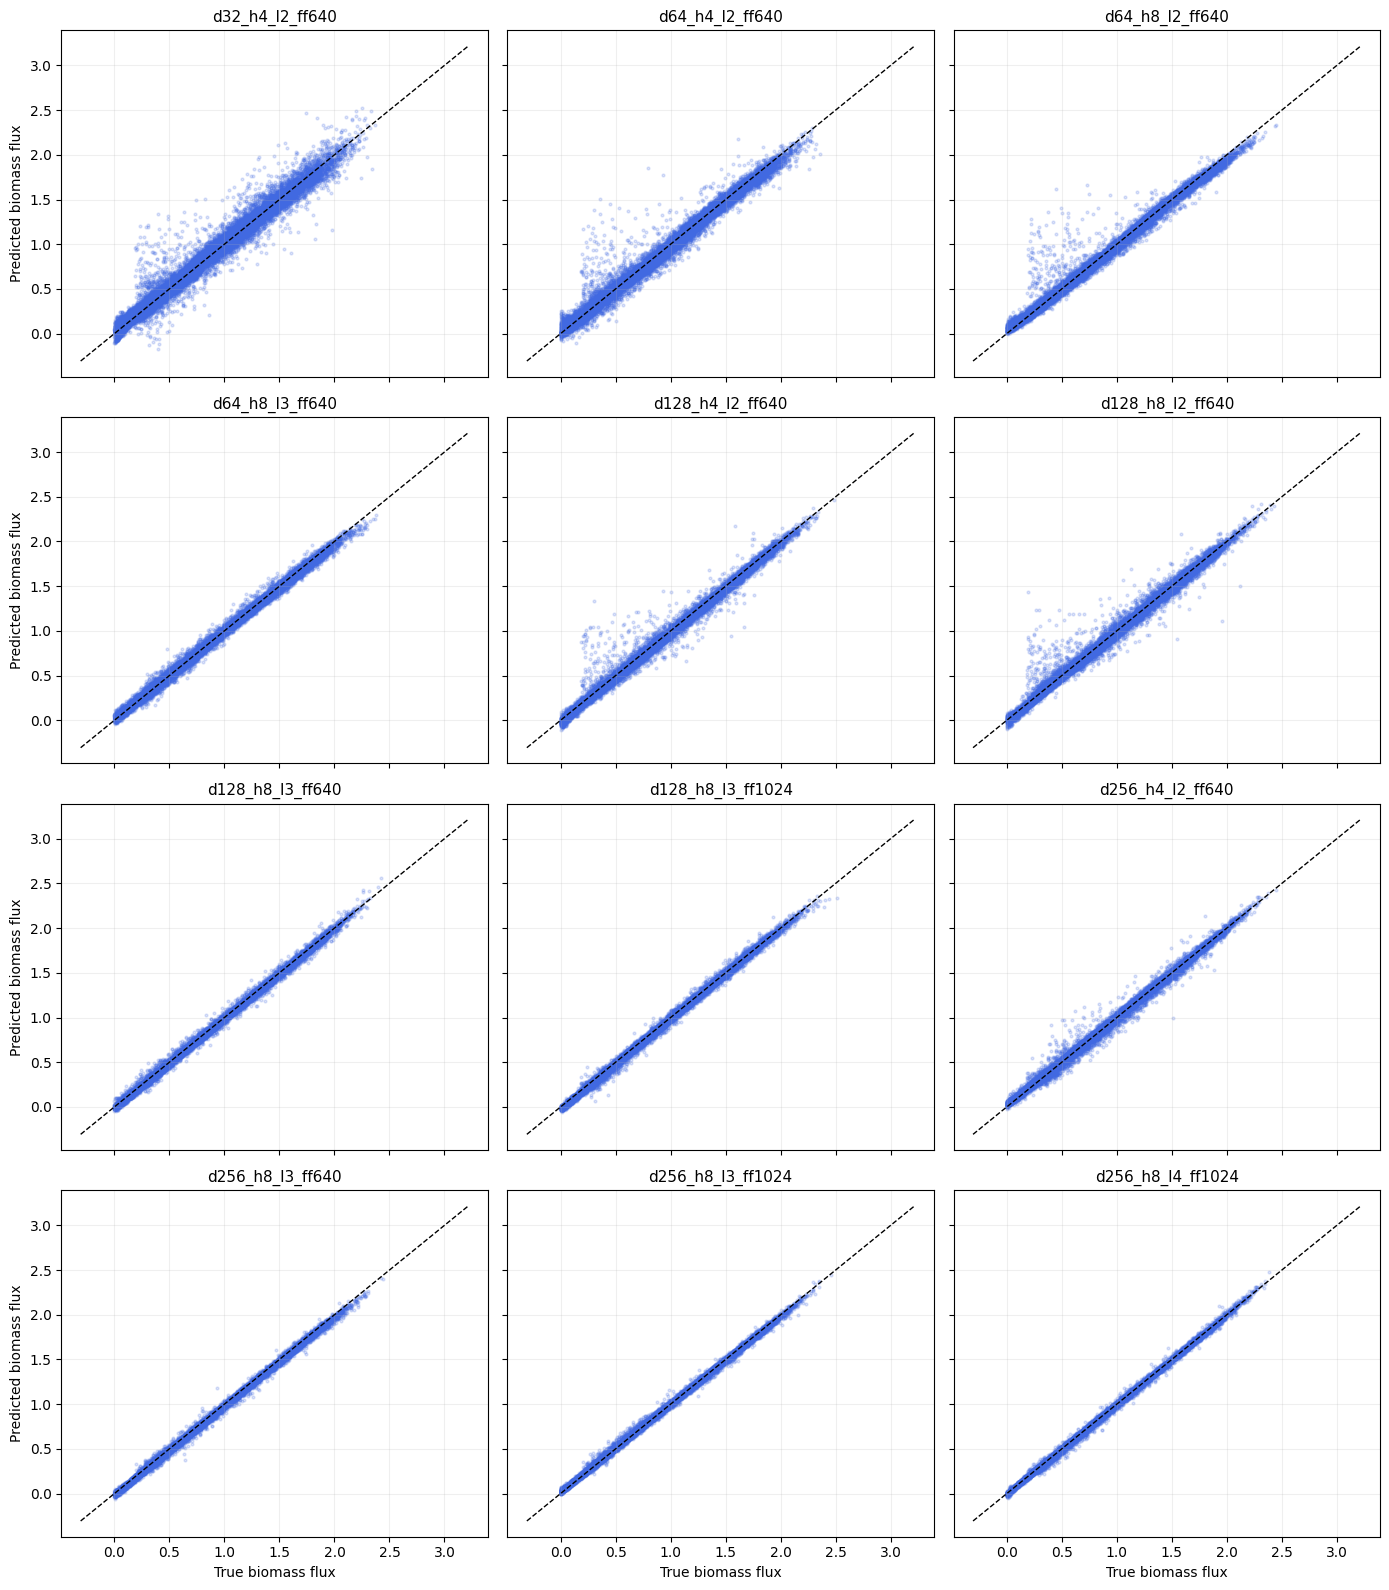

Saved biomass panel comparison to pics\2026-07-03\ecoli_core_architecture_sweep\biomass_flux_model_size_panels.png


In [8]:
try:
    biomass_panels
except NameError:
    biomass_panels = {}

expected_names = [config["name"] for config in MODEL_CONFIGS]
missing_names = [name for name in expected_names if name not in biomass_panels]
if missing_names:
    raise RuntimeError(
        "Run the architecture sweep cell before plotting biomass panels. "
        f"Missing models: {missing_names}"
    )

fig, axes = plt.subplots(4, 3, figsize=(14, 16), sharex=True, sharey=True)
axes = axes.ravel()

global_lo = min(
    min(float(np.min(biomass_panels[name]["true"])), float(np.min(biomass_panels[name]["pred"])))
    for name in expected_names
)
global_hi = max(
    max(float(np.max(biomass_panels[name]["true"])), float(np.max(biomass_panels[name]["pred"])))
    for name in expected_names
)

rng = np.random.default_rng(SEED)
for ax, config in zip(axes, MODEL_CONFIGS):
    name = config["name"]
    y_true_panel = biomass_panels[name]["true"]
    y_pred_panel = biomass_panels[name]["pred"]

    if BIOMASS_PANEL_SAMPLE_COUNT is not None and len(y_true_panel) > BIOMASS_PANEL_SAMPLE_COUNT:
        idx = rng.choice(len(y_true_panel), size=BIOMASS_PANEL_SAMPLE_COUNT, replace=False)
        x_plot = y_true_panel[idx]
        y_plot = y_pred_panel[idx]
    else:
        x_plot = y_true_panel
        y_plot = y_pred_panel

    ax.scatter(x_plot, y_plot, alpha=0.18, s=4, color="royalblue", rasterized=True)
    ax.plot([global_lo, global_hi], [global_lo, global_hi], color="black", linestyle="--", linewidth=1)
    ax.set_title(name, fontsize=11)
    ax.grid(alpha=0.2)

for ax in axes[-3:]:
    ax.set_xlabel("True biomass flux")
for ax in axes[::3]:
    ax.set_ylabel("Predicted biomass flux")

for ax in axes[len(MODEL_CONFIGS):]:
    ax.set_visible(False)

fig.tight_layout()
out_path = PLOT_DIR / "biomass_flux_model_size_panels.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved biomass panel comparison to {out_path}")